<a href="https://colab.research.google.com/github/nkreuzer26/Hist1354_Final/blob/main/NK_GDPPC_Masterlist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GDP per Capita Analysis: US-Backed Military Coups in Latin America

This notebook applies the Synthetic Control Method (SCM) to estimate the economic impact of five US-backed military interventions in Latin America. For each case, a weighted average of comparable countries is constructed as a counterfactual for what the treated country's GDP per capita would have been absent the intervention. The gap between actual and synthetic GDP per capita estimates the intervention's economic effect.

**Case studies:** Chile 1973, Brazil 1964, Dominican Republic 1965, Ecuador 1963, Argentina 1976

**Data sources:** Maddison Project Database 2023 (GDP), Penn World Table 11.0 (human capital, investment), Barro-Lee v2.2 (schooling), REER database (Chile only), AgTFP International (Chile only)

## Shared Setup

All five case studies draw from the same three databases. Data is loaded once here and filtered per case below.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Maddison Project Database 2023
maddison_full = pd.read_excel("mpd2023_web.xlsx", sheet_name="Full data")

# Penn World Table 11.0
pwt_data = pd.read_excel("pwt110.xlsx", sheet_name="Data")

# Barro-Lee Educational Attainment v2.2
schooling_raw = pd.read_excel(
    "BL2013_MF2599_v2.2.xls", sheet_name="Sheet1", header=7
)
schooling_raw["Country"] = schooling_raw["Country"].ffill()
schooling_raw = schooling_raw[schooling_raw["Country"].notna()].copy()

# Match "Avg. Years of Total Schooling" — avoid matching "No Schooling"
school_col = next(
    (c for c in schooling_raw.columns
     if "avg" in str(c).lower() and "schooling" in str(c).lower()), None
) or next(
    (c for c in schooling_raw.columns if "yr_sch" in str(c).lower()), None
)
schooling_data = schooling_raw.rename(columns={
    "Country": "country", "Year": "year", school_col: "school_years"
})[["country", "year", "school_years"]].copy()

print("Maddison:", maddison_full.shape,
      "| PWT:", pwt_data.shape,
      "| Barro-Lee:", schooling_data.shape)

Maddison: (131144, 6) | PWT: (13690, 51) | Barro-Lee: (2478, 3)


---

## Case Study 1: Chile 1973

On September 11, 1973, General Augusto Pinochet led a US-backed military coup that overthrew the democratically elected government of Salvador Allende. The junta dissolved congress, banned leftist parties, and imposed a neoliberal economic program under the influence of the Chicago Boys. This analysis estimates what Chilean GDP per capita would have looked like without the coup, using a weighted average of comparable countries as the counterfactual.

### Parameters and data

In [ ]:
TREATED_COUNTRY = "Chile"
INTERVENTION_YEAR = 1973
PRE_TREATMENT_START = 1960
PRE_TREATMENT_END = 1972
POST_TREATMENT_END = 1993

maddison_cl = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START) &
    (maddison_full["year"] <= POST_TREATMENT_END)
].copy()

### Candidate country screening

Countries are screened by their 1972 GDP per capita relative to Chile's. The ratio window (45%--205%) retains comparable market economies and excludes very poor and very rich countries that would be implausible counterfactuals.

In [ ]:
chile_gdp_1972 = maddison_cl.loc[
    (maddison_cl["country"] == TREATED_COUNTRY) &
    (maddison_cl["year"] == PRE_TREATMENT_END), "gdppc"
].values[0]

gdp_1972 = (
    maddison_cl[maddison_cl["year"] == PRE_TREATMENT_END][["country", "gdppc"]]
    .dropna(subset=["gdppc"])
    .copy()
)
gdp_1972["ratio"] = gdp_1972["gdppc"] / chile_gdp_1972

comparable_cl = gdp_1972[
    (gdp_1972["ratio"] >= 0.45) & (gdp_1972["ratio"] <= 2.05)
].copy()
print(f"Countries in GDP window: {len(comparable_cl)}")

Countries in GDP window: 64


### Exclusion criteria and final donor pool

Countries are excluded for other differences like socialist or command economies, oil-dependent states, Asian Tigers, city-states, countries experiencing overlapping conflicts or coups, and other treated units in this project. The remaining pool of market economies with comparable income levels serves as the donor set.

In [ ]:
EXCLUSION_CL = {
    "Chile": "Treated country",
    "Argentina": "Other treated unit (1976 coup)",
    "Brazil": "Other treated unit (1964 coup)",
    "Dominican Republic": "Other treated unit (1965 coup)",
    "Ecuador": "Other treated unit (1963 coup)",
    "Cuba": "Socialist command economy",
    "Nicaragua": "Somoza regime; civil conflict",
    "Bolivia": "Chronic coups and instability",
    "Bolivia (Plurinational State of)": "Chronic coups and instability",
    "Haiti": "Duvalier dictatorship",
    "Paraguay": "Stroessner dictatorship",
    "Uruguay": "Military coup 1973",
    "Peru": "Velasco military regime from 1968",
    "Panama": "US Canal Zone economic distortion",
    "South Africa": "Apartheid; dual economy",
    "Algeria": "Socialist, nationalized economy",
    "Egypt": "Nasser Arab Socialism",
    "Syrian Arab Republic": "Ba'ath socialist coup 1963",
    "Syria": "Ba'ath socialist coup 1963",
    "Venezuela (Bolivarian Republic of)": "OPEC oil economy",
    "Venezuela": "OPEC oil economy",
    "Libya": "Oil-dependent; Gaddafi 1969",
    "Iran (Islamic Republic of)": "Oil-dependent",
    "Iran": "Oil-dependent",
    "Iraq": "Oil economy; Ba'athist",
    "Saudi Arabia": "Oil monarchy",
    "Trinidad and Tobago": "Oil-dependent",
    "Nigeria": "Oil; civil war",
    "Republic of Korea": "Asian Tiger; military regime",
    "Taiwan, Province of China": "Asian Tiger; KMT single-party",
    "Taiwan": "Asian Tiger; KMT single-party",
    "Singapore": "City-state Tiger",
    "Malaysia": "Tiger Cub",
    "Hong Kong": "City-state; British colony",
    "China, Hong Kong SAR": "City-state",
    "Puerto Rico": "US territory; federal transfers",
    "Former Yugoslavia": "Titoist socialist",
    "Yugoslavia": "Titoist socialist",
    "Romania": "Communist",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Czechoslovakia": "Socialist",
    "Czech Republic": "Former Czechoslovakia",
    "Poland": "Soviet satellite",
    "Albania": "Communist",
    "Former USSR": "Soviet command economy",
    "Russian Federation": "USSR during study period",
    "Lebanon": "Civil war 1975-1990",
    "Viet Nam": "War; communist",
    "Indonesia": "Suharto coup 1965",
    "Thailand": "Military regime",
    "Cambodia": "Khmer Rouge",
    "Jordan": "Incomplete data",
    "Israel": "Military spending distortion",
    "Afghanistan": "Incomplete data",
    "Barbados": "Small island economy",
    "Cyprus": "Small island; conflict",
    "Malta": "Small island",
    "Mauritius": "Small island",
    "Seychelles": "Socialist 1977",
    "Congo": "Socialist",
    "Tunisia": "Single-party state",
    "Guatemala": "Military regime; civil war",
    "El Salvador": "Military regime; civil war",
    "Honduras": "Military regime",
    "Sudan": "Civil war",
    "Sudan (Former)": "Civil war",
    "Angola": "Colonial and civil war",
    "Benin": "Non-Atlantic", "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic", "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic", "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic", "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic", "Guinea-Bissau": "Non-Atlantic",
    "Cote d'Ivoire": "Non-Atlantic", "Côte d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic", "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic", "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic", "United Republic of Tanzania": "Non-Atlantic",
    "Zambia": "Non-Atlantic", "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic", "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic", "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic", "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic", "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic", "Senegal": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "India": "Non-Atlantic", "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic", "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic", "Philippines": "Non-Atlantic",
    "China": "Non-Atlantic",
}

candidates_cl = comparable_cl[~comparable_cl["country"].isin(EXCLUSION_CL)].copy()

study_years_cl = set(range(PRE_TREATMENT_START, POST_TREATMENT_END + 1))
final_donor_pool = []
for _, row in candidates_cl.iterrows():
    c = row["country"]
    c_data = maddison_cl[
        (maddison_cl["country"] == c) & (maddison_cl["year"].isin(study_years_cl))
    ].dropna(subset=["gdppc"])
    if len(c_data) >= len(study_years_cl):
        final_donor_pool.append(c)

print(f"GDP-complete donor pool: {len(final_donor_pool)} countries")

GDP-complete donor pool: 27 countries


### Figure 1: Final donor pool by GDP per capita

Countries retained after GDP screening and exclusion criteria, ranked by their 1972 GDP per capita. Chile's 1972 level is marked with a dashed line.

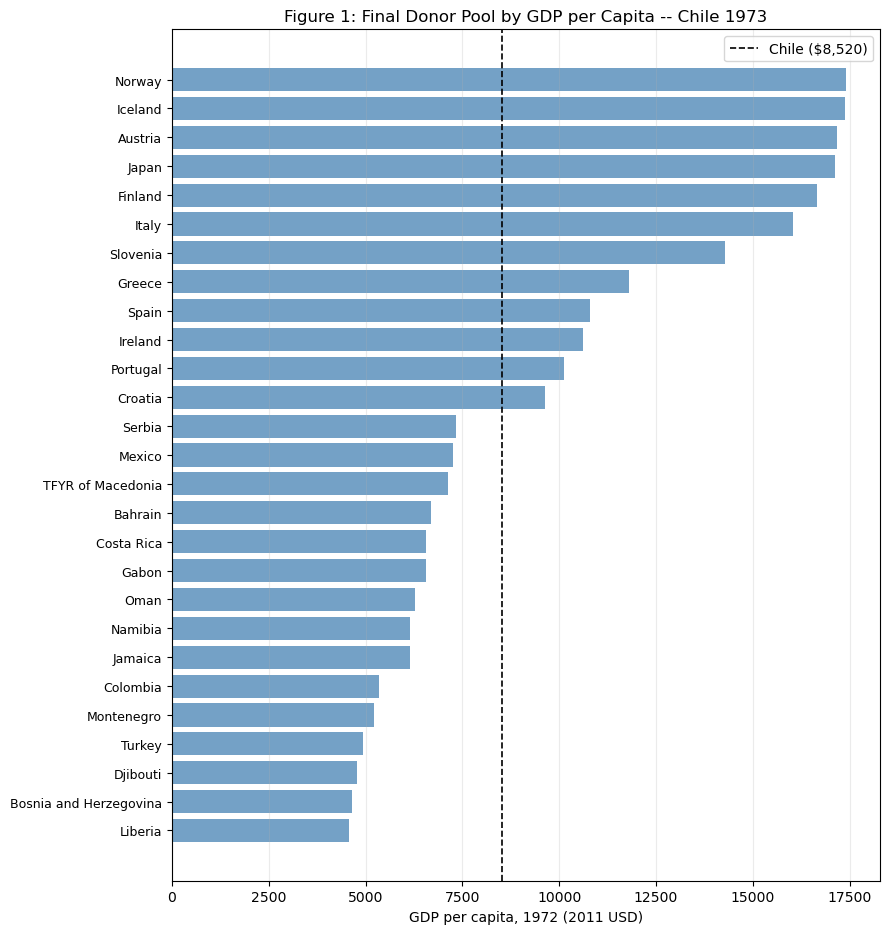

In [ ]:
pool_gdp_cl = (
    gdp_1972[gdp_1972["country"].isin(final_donor_pool)]
    .sort_values("gdppc")
    .copy()
)

fig, ax = plt.subplots(figsize=(9, max(4, len(pool_gdp_cl) * 0.35)))
ax.barh(range(len(pool_gdp_cl)), pool_gdp_cl["gdppc"].values,
        color="steelblue", alpha=0.75)
ax.set_yticks(range(len(pool_gdp_cl)))
ax.set_yticklabels(pool_gdp_cl["country"].values, fontsize=9)
ax.axvline(chile_gdp_1972, color="black", linestyle="--", linewidth=1.2,
           label=f"Chile (${chile_gdp_1972:,.0f})")
ax.set_xlabel("GDP per capita, 1972 (2011 USD)")
ax.set_title("Figure 1: Final Donor Pool by GDP per Capita -- Chile 1973")
ax.legend()
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Build panel and fit synthetic control

The synthetic control uses six predictors via `special_predictors`: three GDP per capita sub-period averages, human capital index (PWT), investment share (PWT), and average years of schooling (Barro-Lee). REER and agricultural TFP are loaded separately for descriptive purposes but cannot be included in the cross-country optimization because donor countries lack those series (due to lack of pre 1965 data). Donors are pre-filtered so that any country with no data for a predictor's time range is dropped before Dataprep is called

In [ ]:
try:
    from pysyncon import Dataprep, Synth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pysyncon", "-q"])
    from pysyncon import Dataprep, Synth

# Barro-Lee name edits
BL_TO_MADDISON_CL = {
    "Korea, Rep.": "Republic of Korea",
    "Venezuela, RB": "Venezuela",
    "Iran, Islamic Rep.": "Iran",
    "Egypt, Arab Rep.": "Egypt",
    "Syrian Arab Rep.": "Syrian Arab Republic",
    "Hong Kong, China": "Hong Kong",
    "Trinidad &Tobago": "Trinidad and Tobago",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Lao PDR": "Laos",
    "Gambia, The": "Gambia",
}
schooling_data_cl = schooling_data.copy()
schooling_data_cl["country"] = schooling_data_cl["country"].replace(BL_TO_MADDISON_CL)

# Build long-format panel --> one row per (unit, year), columns = gdppc, hc, csh_i, school_years
all_units_cl = [TREATED_COUNTRY] + sorted(final_donor_pool)
all_years_cl = list(range(PRE_TREATMENT_START, POST_TREATMENT_END + 1))

outcome_panel_cl = maddison_cl[
    maddison_cl["country"].isin(all_units_cl)
].pivot_table(index="year", columns="country", values="gdppc").reindex(all_years_cl)

panel_long_cl = (
    outcome_panel_cl.reset_index()
    .melt(id_vars="year", var_name="unit", value_name="gdppc")
)
pwt_cl = pwt_data[["country", "year", "hc", "csh_i"]].rename(columns={"country": "unit"})
panel_long_cl = panel_long_cl.merge(pwt_cl, on=["unit", "year"], how="left")
bl_cl = schooling_data_cl[["country", "year", "school_years"]].rename(columns={"country": "unit"})
panel_long_cl = panel_long_cl.merge(bl_cl, on=["unit", "year"], how="left")

# Barro-Lee years available for Chile in the pre-treatment period (5-year snapshots)
bl_years_cl = sorted(
    panel_long_cl[
        (panel_long_cl["unit"] == TREATED_COUNTRY) &
        (panel_long_cl["year"] <= PRE_TREATMENT_END) &
        (panel_long_cl["school_years"].notna())
    ]["year"].values
)
print(f"Barro-Lee years for Chile: {bl_years_cl}")

# Define special predictors -- all reference actual columns in panel_long_cl
special_predictors_cl = [
    ("gdppc",       range(1960, 1965), "mean"),
    ("gdppc",       range(1965, 1970), "mean"),
    ("gdppc",       range(1970, 1973), "mean"),
    ("hc",          range(1960, 1973), "mean"),
    ("csh_i",       range(1960, 1973), "mean"),
    ("school_years", bl_years_cl,     "mean"),
]

# Drop donors that have no data at all for any special predictor's time range
def has_all_preds(unit, panel, specs):
    d = panel[panel["unit"] == unit]
    for col, yrs, _ in specs:
        if d[d["year"].isin(list(yrs))][col].dropna().empty:
            return False
    return True

donor_units_cl = [c for c in sorted(final_donor_pool)
                  if has_all_preds(c, panel_long_cl, special_predictors_cl)]
dropped_cl = set(sorted(final_donor_pool)) - set(donor_units_cl)
if dropped_cl:
    print(f"Dropped for missing predictors: {sorted(dropped_cl)}")
print(f"Final donor pool: {len(donor_units_cl)} countries")

dataprep_cl = Dataprep(
    foo=panel_long_cl,
    predictors=[],
    predictors_op="mean",
    time_predictors_prior=range(PRE_TREATMENT_START, PRE_TREATMENT_END + 1),
    special_predictors=special_predictors_cl,
    dependent="gdppc",
    unit_variable="unit",
    time_variable="year",
    treatment_identifier=TREATED_COUNTRY,
    controls_identifier=donor_units_cl,
    time_optimize_ssr=range(PRE_TREATMENT_START, PRE_TREATMENT_END + 1),
)

synth_cl = Synth()
synth_cl.fit(dataprep=dataprep_cl, optim_method="Nelder-Mead", optim_initial="equal")
print("Model fitted.")

weights_raw_cl = synth_cl.weights(round=4)
if isinstance(weights_raw_cl, pd.Series):
    donor_weights_cl = weights_raw_cl
elif isinstance(weights_raw_cl, pd.DataFrame):
    donor_weights_cl = pd.Series(
        weights_raw_cl.iloc[:, -1].values, index=weights_raw_cl.iloc[:, 0].values
    )
else:
    donor_weights_cl = pd.Series(weights_raw_cl, index=donor_units_cl)
donor_weights_cl = donor_weights_cl.sort_values(ascending=False)

print("\nDonor weights:")
for c, w in donor_weights_cl.items():
    if w > 0.001:
        print(f"  {c:30s} {w:.4f}")

Barro-Lee years for Chile: [np.int64(1960), np.int64(1965), np.int64(1970)]
Dropped for missing predictors: ['Bosnia and Herzegovina', 'Croatia', 'Djibouti', 'Montenegro', 'Oman', 'Serbia', 'Slovenia', 'TFYR of Macedonia', 'Turkey']
Final donor pool: 18 countries
Model fitted.

Donor weights:
  Ireland                        0.5210
  Namibia                        0.2920
  Colombia                       0.1228
  Norway                         0.0643


### Pre-treatment fit

In [ ]:
# Reconstruct synthetic series from panel and weights
actual_cl = outcome_panel_cl[TREATED_COUNTRY]
synthetic_cl = outcome_panel_cl[donor_weights_cl.index] @ donor_weights_cl

pre_mask_cl = actual_cl.index <= PRE_TREATMENT_END
rmspe_cl = np.sqrt(((actual_cl[pre_mask_cl] - synthetic_cl[pre_mask_cl]) ** 2).mean())
corr_cl = actual_cl[pre_mask_cl].corr(synthetic_cl[pre_mask_cl])
print(f"Pre-treatment RMSPE:        {rmspe_cl:.1f}")
print(f"Pre-treatment correlation:  {corr_cl:.4f}")

Pre-treatment RMSPE:        354.2
Pre-treatment correlation:  0.9562


### Figure 2: Donor pool by SCM weights

After fitting, countries with nonzero weight in the synthetic Chile are shown ranked by their assigned weights

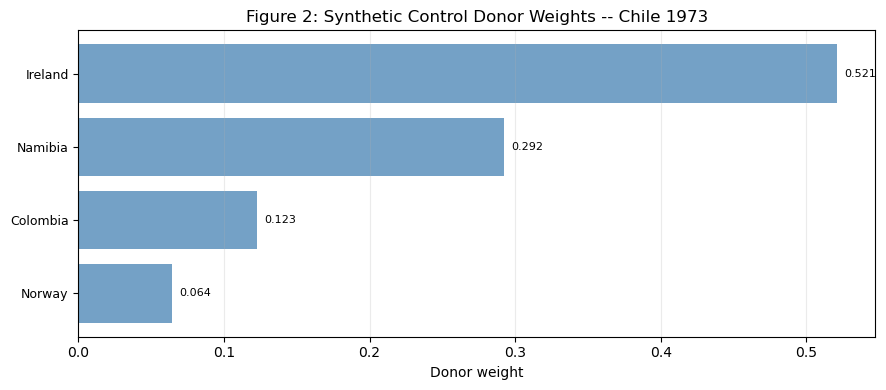

In [ ]:
nonzero_cl = donor_weights_cl[donor_weights_cl > 0.001].sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, len(nonzero_cl) * 0.38)))
ax.barh(range(len(nonzero_cl)), nonzero_cl.values, color="steelblue", alpha=0.75)
ax.set_yticks(range(len(nonzero_cl)))
ax.set_yticklabels(nonzero_cl.index, fontsize=9)
for i, w in enumerate(nonzero_cl.values):
    ax.text(w + 0.005, i, f"{w:.3f}", va="center", fontsize=8)
ax.set_xlabel("Donor weight")
ax.set_title("Figure 2: Synthetic Control Donor Weights -- Chile 1973")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Figure 3: Actual vs Synthetic Chile GDP per Capita

The correlation (closer to 1) and RMSPE (lower) over the pre-treatment period measure how well the synthetic control tracks Chile before the coup.

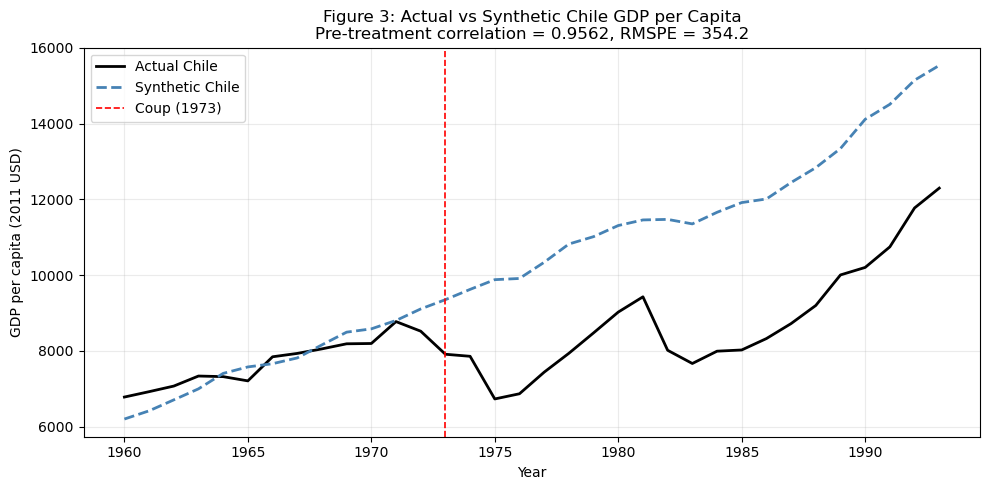

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(actual_cl.index, actual_cl.values,
        color="black", linewidth=2, label="Actual Chile")
ax.plot(synthetic_cl.index, synthetic_cl.values,
        color="steelblue", linewidth=2, linestyle="--", label="Synthetic Chile")
ax.axvline(INTERVENTION_YEAR, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR})")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita (2011 USD)")
ax.set_title(
    f"Figure 3: Actual vs Synthetic Chile GDP per Capita\n"
    f"Pre-treatment correlation = {corr_cl:.4f}, RMSPE = {rmspe_cl:.1f}"
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Figure 4: Per-capita GDP gap

The gap (actual minus synthetic) is negative when the coup reduced GDP per capita relative to the counterfactual. The vertical line marks the intervention year.

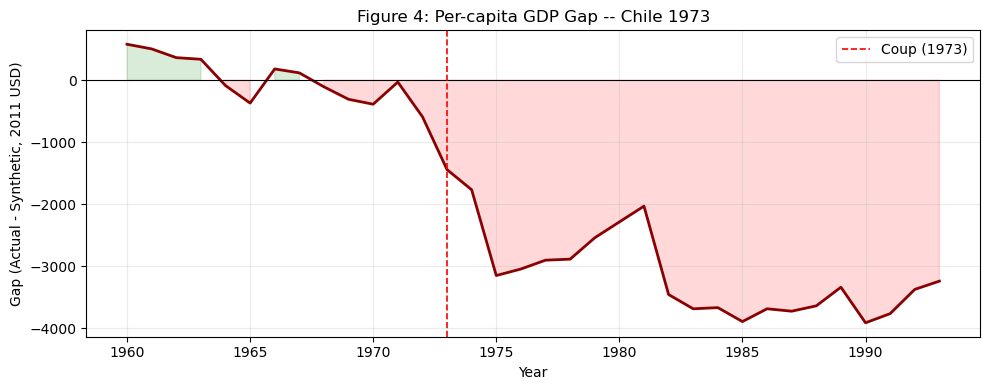

In [ ]:
gap_cl = actual_cl - synthetic_cl

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gap_cl.index, gap_cl.values, color="darkred", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(INTERVENTION_YEAR, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR})")
ax.fill_between(gap_cl.index, gap_cl.values, 0,
                where=(gap_cl.values < 0), alpha=0.15, color="red")
ax.fill_between(gap_cl.index, gap_cl.values, 0,
                where=(gap_cl.values >= 0), alpha=0.15, color="green")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (Actual - Synthetic, 2011 USD)")
ax.set_title("Figure 4: Per-capita GDP Gap -- Chile 1973")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation and limitations

The post-1973 gap in Figure 3 and the sustained negative gap in Figure 4 indicate that Chilean GDP per capita fell below its synthetic counterfactual following the coup. The magnitude and persistence of this gap provides an estimate of the economic cost attributable to the political intervention, holding other factors constant through the donor weights. Altogether this suggests, the coup had a negative impact on Chile's GDP per capita.

**Limitations:** The REER and AgTFP datasets cannot be used in the other case studies (due to missing data coverage), the optimizer uses only GDP sub-periods, human capital, investment, and schooling. Second, the 1973 oil shock affected many potential donors differently from Chile, which could affect the post-treatment comparison. Lastly, some retained donor countries may have experienced political transitions during the post-treatment window that alter the credibility of the counterfactual.

---

## Case Study 2: Brazil 1964

On April 1, 1964, a US-backed military coup overthrew President Joao Goulart, who had been pursuing land reform and nationalization. The military dictatorship that followed lasted until 1985. This analysis estimates what Brazilian GDP per capita would have been without the coup, using a synthetic control constructed from comparable countries that did not experience a US-backed intervention in 1964.

### Parameters and data

In [ ]:
TREATED_COUNTRY_BR = "Brazil"
INTERVENTION_YEAR_BR = 1964
PRE_TREATMENT_START_BR = 1950
PRE_TREATMENT_END_BR = 1963
POST_TREATMENT_END_BR = 2000

maddison_br = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_BR) &
    (maddison_full["year"] <= POST_TREATMENT_END_BR)
].copy()

### Candidate country screening

Countries are screened by their 1963 GDP per capita relative to Brazil's. The ratio window (25%--300%) is wider than Chile's to represent Brazil's lower income level, retaining a broader set of Atlantic-economy comparators.

In [ ]:
br_gdp_1963 = maddison_br.loc[
    (maddison_br["country"] == TREATED_COUNTRY_BR) &
    (maddison_br["year"] == PRE_TREATMENT_END_BR), "gdppc"
].values[0]

gdp_1963 = (
    maddison_br[maddison_br["year"] == PRE_TREATMENT_END_BR][["country", "gdppc"]]
    .dropna(subset=["gdppc"])
    .copy()
)
gdp_1963["ratio"] = gdp_1963["gdppc"] / br_gdp_1963

comparable_br = gdp_1963[
    (gdp_1963["ratio"] >= 0.25) & (gdp_1963["ratio"] <= 3.00)
].copy()
print(f"Countries in GDP window: {len(comparable_br)}")

Countries in GDP window: 121


### Exclusion criteria and final donor pool

In [ ]:
EXCLUSIONS_BR = {
    "Brazil": "Treated country",
    "Chile": "Other treated unit (1973 coup)",
    "Dominican Republic": "Other treated unit (1965 coup)",
    "Ecuador": "Military coup July 1963",
    "Guatemala": "Military coup March 1963; ongoing instability",
    "Bolivia": "Barrientos coup November 1964; chronic instability",
    "Bolivia (Plurinational State of)": "Barrientos coup November 1964",
    "Thailand": "Sarit/Thanom military regimes",
    "Viet Nam": "Multiple coups 1963-1964",
    "Indonesia": "Suharto coup October 1965; mass killings",
    "Cuba": "Castro socialist command economy from 1959",
    "Haiti": "Duvalier dictatorship from 1957",
    "Nicaragua": "Somoza family dynastic rule",
    "Panama": "US Canal Zone economic distortion",
    "South Africa": "Apartheid regime; dual economy",
    "Algeria": "Ben Bella one-party state; nationalized economy",
    "Egypt": "Nasser Arab Socialism",
    "Syrian Arab Republic": "Ba'ath Arab Socialist coup 1963",
    "Syria": "Ba'ath Arab Socialist coup 1963",
    "Romania": "Communist regime",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Hoxha communist regime",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Titoist socialist federation",
    "Yugoslavia": "Titoist socialist federation",
    "Croatia": "Part of socialist Yugoslavia",
    "Slovenia": "Part of socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav successor state",
    "Serbia": "Post-Yugoslav successor state",
    "Montenegro": "Post-Yugoslav successor state",
    "Macedonia": "Post-Yugoslav successor state",
    "TFYR of Macedonia": "Post-Yugoslav successor state",
    "Former USSR": "Soviet command economy",
    "Russian Federation": "USSR during study period",
    "Czechoslovakia": "Socialist 1948-1989",
    "Czech Republic": "Former Czechoslovakia, socialist",
    "Seychelles": "Socialist one-party state from 1977",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party state, state-directed economy",
    "Yemen": "Socialist 1967-1990",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil-dominated",
    "Venezuela": "OPEC; oil-dominated",
    "Libya": "Oil-dependent; Gaddafi revolution 1969",
    "Iran (Islamic Republic of)": "Oil-dependent",
    "Iran": "Oil-dependent",
    "Gabon": "Oil economy",
    "Iraq": "Oil economy",
    "Bahrain": "Oil-dependent Gulf state",
    "Saudi Arabia": "Oil-dependent monarchy",
    "Trinidad and Tobago": "Oil-dependent economy",
    "Equatorial Guinea": "Oil economy",
    "Oman": "Oil economy",
    "Nigeria": "Oil economy; Biafra civil war 1967-1970",
    "Republic of Korea": "Asian Tiger; Park military from 1961",
    "Taiwan, Province of China": "Asian Tiger; KMT single-party",
    "Taiwan": "Asian Tiger; KMT single-party",
    "Malaysia": "Tiger Cub economy",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state; British Crown Colony",
    "Hong Kong": "City-state; British Crown Colony",
    "Puerto Rico": "US territory; federal transfers",
    "Barbados": "Small island economy",
    "Cyprus": "Small island; communal conflict",
    "Mauritius": "Small island economy",
    "Malta": "Small island; British military base",
    "Djibouti": "French colonial territory until 1977",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island economy",
    "Lebanon": "Civil war 1975-1990",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Tubman-era proxy state; coup 1980",
    "Namibia": "UNITA conflict spillover",
    "Swaziland": "ANC cross-border conflicts",
    "Angola": "Colonial war; civil war",
    "Cambodia": "Khmer Rouge ascendancy",
    "Sudan": "First Sudanese Civil War 1955-1972",
    "Sudan (Former)": "First Sudanese Civil War",
    "Palestine": "Incomplete data",
    "State of Palestine": "Incomplete data",
    "Jordan": "Incomplete predictor coverage",
    "Israel": "Yom Kippur War; military spending distortion",
    "Afghanistan": "Incomplete predictor coverage",
    "Benin": "Non-Atlantic", "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic", "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic", "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic", "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic", "Guinea-Bissau": "Non-Atlantic",
    "Cote d'Ivoire": "Non-Atlantic", "Côte d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic", "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic", "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic", "United Republic of Tanzania": "Non-Atlantic",
    "Zambia": "Non-Atlantic", "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic", "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic", "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic", "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic", "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic", "Senegal": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic", "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic", "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic", "Philippines": "Non-Atlantic",
    "China": "Non-Atlantic",
}

candidates_br = comparable_br[~comparable_br["country"].isin(EXCLUSIONS_BR)].copy()

study_years_br = set(range(PRE_TREATMENT_START_BR, POST_TREATMENT_END_BR + 1))
final_donor_pool_br = []
dropped_br = []
for _, row in candidates_br.iterrows():
    c = row["country"]
    c_data = maddison_br[
        (maddison_br["country"] == c) & (maddison_br["year"].isin(study_years_br))
    ].dropna(subset=["gdppc"])
    if len(c_data) >= len(study_years_br):
        final_donor_pool_br.append(c)
    else:
        dropped_br.append((c, len(c_data)))

if dropped_br:
    print(f"Dropped for incomplete GDP coverage:")
    for c, n in dropped_br:
        print(f"  {c}: {n}/{len(study_years_br)} years")
print(f"Final donor pool: {len(final_donor_pool_br)} countries")

Final donor pool: 18 countries


### Figure 1: Final donor pool by GDP per capita

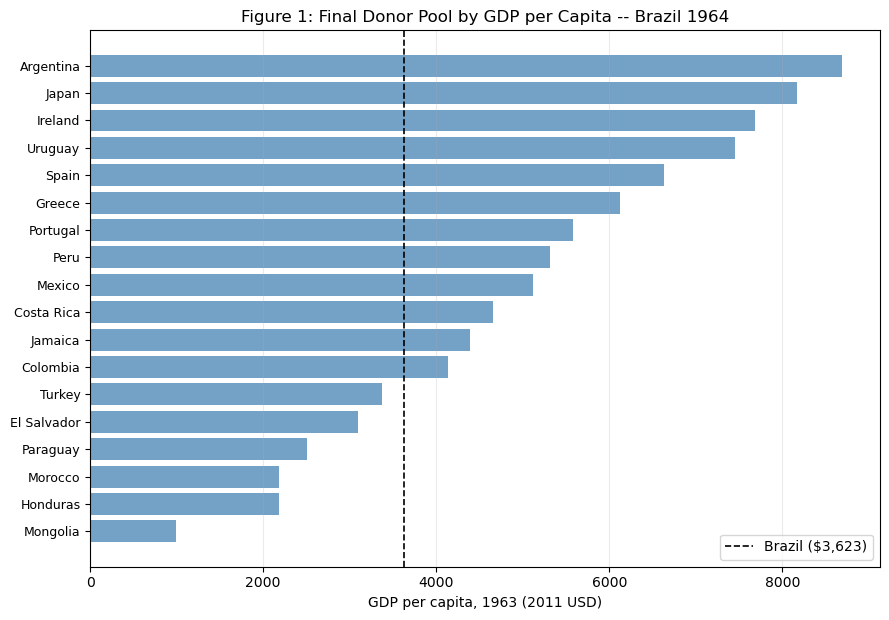

In [ ]:
pool_gdp_br = (
    gdp_1963[gdp_1963["country"].isin(final_donor_pool_br)]
    .sort_values("gdppc")
    .copy()
)

fig, ax = plt.subplots(figsize=(9, max(4, len(pool_gdp_br) * 0.35)))
ax.barh(range(len(pool_gdp_br)), pool_gdp_br["gdppc"].values,
        color="steelblue", alpha=0.75)
ax.set_yticks(range(len(pool_gdp_br)))
ax.set_yticklabels(pool_gdp_br["country"].values, fontsize=9)
ax.axvline(br_gdp_1963, color="black", linestyle="--", linewidth=1.2,
           label=f"Brazil (${br_gdp_1963:,.0f})")
ax.set_xlabel("GDP per capita, 1963 (2011 USD)")
ax.set_title("Figure 1: Final Donor Pool by GDP per Capita -- Brazil 1964")
ax.legend()
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Build panel and fit synthetic control

The non-Chile cases use a reduced predictor set: three GDP sub-period averages, human capital (PWT), investment share (PWT), and schooling (Barro-Lee). Donors missing data for any predictor's time range are dropped before calling Dataprep.

In [ ]:
BL_TO_MADDISON_BR = {
    "Dominican Rep.": "Dominican Republic",
    "Korea, Rep.": "Republic of Korea",
    "Venezuela, RB": "Venezuela",
    "Iran, Islamic Rep.": "Iran",
    "Egypt, Arab Rep.": "Egypt",
    "Syrian Arab Rep.": "Syrian Arab Republic",
    "Hong Kong, China": "Hong Kong",
    "Trinidad &Tobago": "Trinidad and Tobago",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Central African Rep.": "Central African Republic",
    "Lao PDR": "Laos",
    "Gambia, The": "Gambia",
}
schooling_data_br = schooling_data.copy()
schooling_data_br["country"] = schooling_data_br["country"].replace(BL_TO_MADDISON_BR)

all_units_br = [TREATED_COUNTRY_BR] + sorted(final_donor_pool_br)
all_years_br = list(range(PRE_TREATMENT_START_BR, POST_TREATMENT_END_BR + 1))

outcome_panel_br = maddison_br[
    maddison_br["country"].isin(all_units_br)
].pivot_table(index="year", columns="country", values="gdppc").reindex(all_years_br)

for c in outcome_panel_br.columns:
    n_nan = outcome_panel_br[c].isna().sum()
    if 0 < n_nan <= 2:
        outcome_panel_br[c] = outcome_panel_br[c].interpolate(method="linear")

panel_long_br = (
    outcome_panel_br.reset_index()
    .melt(id_vars="year", var_name="unit", value_name="gdppc")
)
pwt_br = pwt_data[["country", "year", "hc", "csh_i"]].rename(columns={"country": "unit"})
panel_long_br = panel_long_br.merge(pwt_br, on=["unit", "year"], how="left")
bl_br = schooling_data_br[["country", "year", "school_years"]].rename(columns={"country": "unit"})
panel_long_br = panel_long_br.merge(bl_br, on=["unit", "year"], how="left")

bl_years_br = sorted(
    panel_long_br[
        (panel_long_br["unit"] == TREATED_COUNTRY_BR) &
        (panel_long_br["year"] <= PRE_TREATMENT_END_BR) &
        (panel_long_br["school_years"].notna())
    ]["year"].values
)

special_predictors_br = [
    ("gdppc",       range(1950, 1955), "mean"),
    ("gdppc",       range(1955, 1960), "mean"),
    ("gdppc",       range(1960, 1964), "mean"),
    ("hc",          range(1951, 1964), "mean"),
    ("csh_i",       range(1960, 1964), "mean"),
    ("school_years", bl_years_br,     "mean"),
]

donor_units_br = [c for c in sorted(final_donor_pool_br)
                  if has_all_preds(c, panel_long_br, special_predictors_br)]
dropped_pred_br = set(sorted(final_donor_pool_br)) - set(donor_units_br)
if dropped_pred_br:
    print(f"Dropped for missing predictors: {sorted(dropped_pred_br)}")
print(f"Final donor pool after predictor check: {len(donor_units_br)}")

dataprep_br = Dataprep(
    foo=panel_long_br,
    predictors=[],
    predictors_op="mean",
    time_predictors_prior=range(PRE_TREATMENT_START_BR, PRE_TREATMENT_END_BR + 1),
    special_predictors=special_predictors_br,
    dependent="gdppc",
    unit_variable="unit",
    time_variable="year",
    treatment_identifier=TREATED_COUNTRY_BR,
    controls_identifier=donor_units_br,
    time_optimize_ssr=range(PRE_TREATMENT_START_BR, PRE_TREATMENT_END_BR + 1),
)

synth_br = Synth()
synth_br.fit(dataprep=dataprep_br, optim_method="Nelder-Mead", optim_initial="equal")
print("Model fitted.")

weights_raw_br = synth_br.weights(round=4)
if isinstance(weights_raw_br, pd.Series):
    donor_weights_br = weights_raw_br
elif isinstance(weights_raw_br, pd.DataFrame):
    donor_weights_br = pd.Series(
        weights_raw_br.iloc[:, -1].values, index=weights_raw_br.iloc[:, 0].values
    )
else:
    donor_weights_br = pd.Series(weights_raw_br, index=donor_units_br)
donor_weights_br = donor_weights_br.sort_values(ascending=False)

print("\nDonor weights:")
for c, w in donor_weights_br.items():
    if w > 0.001:
        print(f"  {c:30s} {w:.4f}")

Dropped for missing predictors: ['Mongolia', 'Turkey']
Final donor pool after predictor check: 16
Model fitted.

Donor weights:
  Honduras                       0.3169
  Jamaica                        0.3033
  Morocco                        0.2404
  Japan                          0.0708
  Portugal                       0.0686


### Pre-treatment fit

In [ ]:
actual_br = outcome_panel_br[TREATED_COUNTRY_BR]
synthetic_br = outcome_panel_br[donor_weights_br.index] @ donor_weights_br

pre_mask_br = actual_br.index <= PRE_TREATMENT_END_BR
rmspe_br = np.sqrt(((actual_br[pre_mask_br] - synthetic_br[pre_mask_br]) ** 2).mean())
corr_br = actual_br[pre_mask_br].corr(synthetic_br[pre_mask_br])
print(f"Pre-treatment RMSPE:        {rmspe_br:.1f}")
print(f"Pre-treatment correlation:  {corr_br:.4f}")

Pre-treatment RMSPE:        162.8
Pre-treatment correlation:  0.9696


### Figure 2: Donor pool by SCM weights

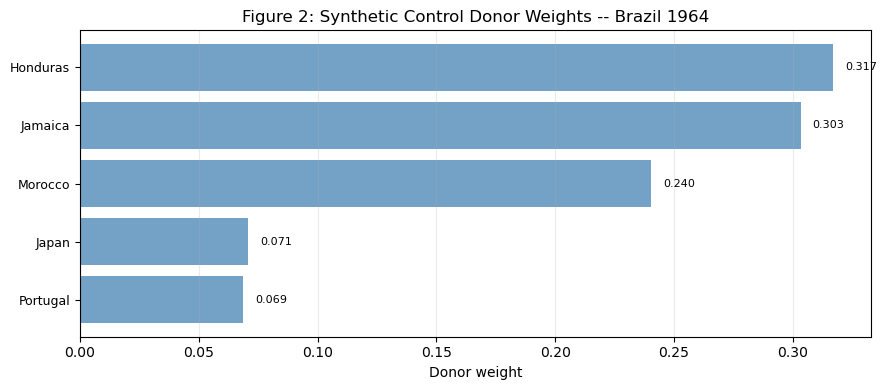

In [ ]:
nonzero_br = donor_weights_br[donor_weights_br > 0.001].sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, len(nonzero_br) * 0.38)))
ax.barh(range(len(nonzero_br)), nonzero_br.values, color="steelblue", alpha=0.75)
ax.set_yticks(range(len(nonzero_br)))
ax.set_yticklabels(nonzero_br.index, fontsize=9)
for i, w in enumerate(nonzero_br.values):
    ax.text(w + 0.005, i, f"{w:.3f}", va="center", fontsize=8)
ax.set_xlabel("Donor weight")
ax.set_title("Figure 2: Synthetic Control Donor Weights -- Brazil 1964")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Figure 3: Actual vs Synthetic Brazil GDP per Capita

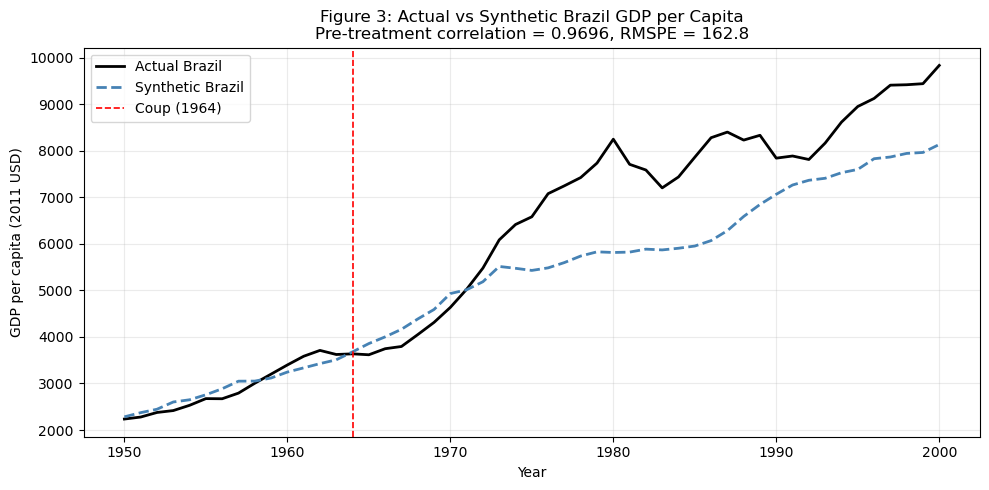

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(actual_br.index, actual_br.values, color="black", linewidth=2, label="Actual Brazil")
ax.plot(synthetic_br.index, synthetic_br.values, color="steelblue",
        linewidth=2, linestyle="--", label="Synthetic Brazil")
ax.axvline(INTERVENTION_YEAR_BR, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR_BR})")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita (2011 USD)")
ax.set_title(
    f"Figure 3: Actual vs Synthetic Brazil GDP per Capita\n"
    f"Pre-treatment correlation = {corr_br:.4f}, RMSPE = {rmspe_br:.1f}"
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Figure 4: Per-capita GDP gap

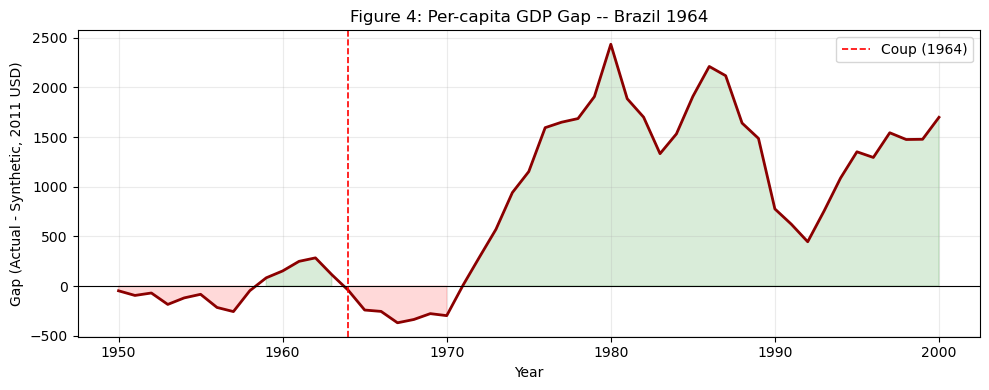

In [ ]:
gap_br = actual_br - synthetic_br

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gap_br.index, gap_br.values, color="darkred", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(INTERVENTION_YEAR_BR, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR_BR})")
ax.fill_between(gap_br.index, gap_br.values, 0,
                where=(gap_br.values < 0), alpha=0.15, color="red")
ax.fill_between(gap_br.index, gap_br.values, 0,
                where=(gap_br.values >= 0), alpha=0.15, color="green")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (Actual - Synthetic, 2011 USD)")
ax.set_title("Figure 4: Per-capita GDP Gap -- Brazil 1964")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation and limitations

The gap between actual and synthetic Brazilian GDP per capita following 1964 provides an estimate of the military dictatorship's economic effect. The donor pool includes Latin American, European, and other Atlantic-economy countries that shared comparable income levels and market structures in the early 1960s. Unlike Chile, where actual GDP fell consistently below the synthetic counterfactual, Brazil's trajectory shows the opposite pattern. After a brief dip right after the coup, actual GDP per capita pulls above the synthetic from around 1970 onward and remains there through 2000. This likely reflects the military government's aggressive state-led industrialization program, which channeled foreign borrowing and public investment into infrastructure and heavy industry at a pace that the counterfactual donors, most of which followed more cautious fiscal paths, did not match. Whether this outperformance represents a genuine long-run gain or just growth borrowed from the future through unsustainable debt accumulation is difficult to determine from GDP per capita, especially given the severity of Brazil's 1980s debt crisis and hyperinflation.


---

## Case Study 3: Dominican Republic 1965

In April 1965, civil conflict after the 1963 oust of President Juan Bosch escalated into a full military confrontation. The US deployed over 40,000 troops under Operation Power Pack, ending the conflict and consolidating military control under Joaquin Balaguer, who held power (directly or indirectly) until 1978. This analysis estimates the GDP per capita cost of that intervention using a synthetic control constructed from comparable market economies.

### Parameters and data

In [ ]:
TREATED_COUNTRY_DR = "Dominican Republic"
INTERVENTION_YEAR_DR = 1965
PRE_TREATMENT_START_DR = 1950
PRE_TREATMENT_END_DR = 1964
POST_TREATMENT_END_DR = 2000

maddison_dr = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_DR) &
    (maddison_full["year"] <= POST_TREATMENT_END_DR)
].copy()

### Candidate country screening

The DR's 1964 GDP per capita is low relative to most Atlantic-economy comparators. The upper ceiling is set at 300% of DR's 1964 GDP to retain Spain, Greece, Portugal, Peru, and Mexico while the 25% floor excludes very poor economies.

In [ ]:
dr_gdp_1964 = maddison_dr.loc[
    (maddison_dr["country"] == TREATED_COUNTRY_DR) &
    (maddison_dr["year"] == PRE_TREATMENT_END_DR), "gdppc"
].values[0]

gdp_1964 = (
    maddison_dr[maddison_dr["year"] == PRE_TREATMENT_END_DR][["country", "gdppc"]]
    .dropna(subset=["gdppc"])
    .copy()
)
gdp_1964["ratio"] = gdp_1964["gdppc"] / dr_gdp_1964

comparable_dr = gdp_1964[
    (gdp_1964["ratio"] >= 0.25) & (gdp_1964["ratio"] <= 3.00)
].copy()
print(f"Countries in GDP window: {len(comparable_dr)}")

Countries in GDP window: 119


### Exclusion criteria and final donor pool

Exclusions follow the same logic as Brazil, adjusted for the 1965 treatment date. Hard exclusions include socialist/command economies, oil-dependent states, Asian Tigers, city-states, active conflict zones, and other treated units in this project.

In [ ]:
EXCLUSIONS_DR = {
    "Dominican Republic": "Treated country",
    "Cuba": "Castro socialist command economy from 1959",
    "Haiti": "Duvalier dictatorship from 1957",
    "Nicaragua": "Somoza family dynastic rule",
    "Brazil": "Castelo Branco coup April 1964; other treated unit in this project",
    "Chile": "Other treated unit (1973 coup)",
    "Thailand": "Sarit/Thanom military regimes; coup 1964",
    "Bolivia": "Barrientos coup November 1964; chronic instability",
    "Bolivia (Plurinational State of)": "Barrientos coup November 1964",
    "Viet Nam": "Multiple coups 1963-1964",
    "Indonesia": "Suharto coup October 1965",
    "Panama": "US Canal Zone economic distortion",
    "South Africa": "Apartheid regime; dual economy",
    "Algeria": "Ben Bella one-party state; nationalized economy",
    "Egypt": "Nasser Arab Socialism",
    "Syrian Arab Republic": "Ba'ath Arab Socialist coup 1963",
    "Syria": "Ba'ath Arab Socialist coup 1963",
    "Romania": "Communist regime",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Hoxha communist regime",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Titoist socialist federation",
    "Yugoslavia": "Titoist socialist federation",
    "Croatia": "Part of socialist Yugoslavia",
    "Slovenia": "Part of socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav successor state",
    "Serbia": "Post-Yugoslav successor state",
    "Montenegro": "Post-Yugoslav successor state",
    "Macedonia": "Post-Yugoslav successor state",
    "TFYR of Macedonia": "Post-Yugoslav successor state",
    "Former USSR": "Soviet command economy",
    "Russian Federation": "USSR during study period",
    "Czechoslovakia": "Socialist 1948-1989",
    "Czech Republic": "Former Czechoslovakia, socialist",
    "Seychelles": "Socialist one-party state from 1977",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party state, state-directed economy",
    "Yemen": "Socialist 1967-1990",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil-dominated",
    "Venezuela": "OPEC; oil-dominated",
    "Libya": "Oil-dependent; Gaddafi revolution 1969",
    "Iran (Islamic Republic of)": "Oil-dependent",
    "Iran": "Oil-dependent",
    "Gabon": "Oil economy",
    "Iraq": "Oil economy",
    "Bahrain": "Oil-dependent Gulf state",
    "Saudi Arabia": "Oil-dependent monarchy",
    "Trinidad and Tobago": "Oil-dependent economy",
    "Equatorial Guinea": "Oil economy",
    "Oman": "Oil economy",
    "Nigeria": "Oil economy; Biafra civil war 1967-1970",
    "Republic of Korea": "Asian Tiger; Park military from 1961",
    "Taiwan, Province of China": "Asian Tiger; KMT single-party",
    "Taiwan": "Asian Tiger; KMT single-party",
    "Malaysia": "Tiger Cub economy",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state; British Crown Colony",
    "Hong Kong": "City-state; British Crown Colony",
    "Puerto Rico": "US territory; federal transfers",
    "Barbados": "Small island economy",
    "Cyprus": "Small island; communal conflict",
    "Mauritius": "Small island economy",
    "Malta": "Small island; British military base",
    "Djibouti": "French colonial territory until 1977",
    "Saint Lucia": "Micro-economy",
    "Lebanon": "Civil war 1975-1990",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Tubman-era proxy state; coup 1980",
    "Namibia": "UNITA conflict spillover",
    "Swaziland": "ANC cross-border conflicts",
    "Angola": "Colonial war; civil war",
    "Cambodia": "Khmer Rouge ascendancy",
    "Sudan": "First Sudanese Civil War 1955-1972",
    "Sudan (Former)": "First Sudanese Civil War",
    "Palestine": "Incomplete data",
    "State of Palestine": "Incomplete data",
    "Jordan": "Incomplete predictor coverage",
    "Israel": "Yom Kippur War; military spending distortion",
    "Afghanistan": "Incomplete predictor coverage",
    "Benin": "Non-Atlantic", "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic", "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic", "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic", "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic", "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic", "Cote d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic", "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic", "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic", "United Republic of Tanzania": "Non-Atlantic",
    "Zambia": "Non-Atlantic", "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic", "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic", "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic", "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic", "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic", "Senegal": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic", "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic", "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic", "Philippines": "Non-Atlantic",
    "China": "Non-Atlantic",
}

# Countries retained despite marginal political status
RETAINED_NOTES_DR = {
    "Guatemala": "Coup March 1963, 25 months before DR; CA peer. Limitation.",
    "El Salvador": "Military junta but market economy; CA peer. Limitation.",
    "Ecuador": "Coup July 1963, 24 months before DR; Andean peer. Limitation.",
    "Paraguay": "Stroessner authoritarian but market economy. Limitation.",
    "Jamaica": "Caribbean peer structurally comparable to DR.",
    "Peru": "Democratic through 1968; Andean market economy.",
    "Colombia": "Democratic through period; key Latin American comparator.",
}

candidates_dr = comparable_dr[~comparable_dr["country"].isin(EXCLUSIONS_DR)].copy()

study_years_dr = set(range(PRE_TREATMENT_START_DR, POST_TREATMENT_END_DR + 1))
final_donor_pool_dr = []
dropped_dr = []
for _, row in candidates_dr.iterrows():
    c = row["country"]
    c_data = maddison_dr[
        (maddison_dr["country"] == c) & (maddison_dr["year"].isin(study_years_dr))
    ].dropna(subset=["gdppc"])
    if len(c_data) >= len(study_years_dr):
        final_donor_pool_dr.append(c)
    else:
        dropped_dr.append((c, len(c_data)))

if dropped_dr:
    print("Dropped for incomplete GDP coverage:")
    for c, n in dropped_dr:
        print(f"  {c}: {n}/{len(study_years_dr)} years")
print(f"Final donor pool: {len(final_donor_pool_dr)} countries")

Final donor pool: 21 countries


### Figure 1: Final donor pool by GDP per capita

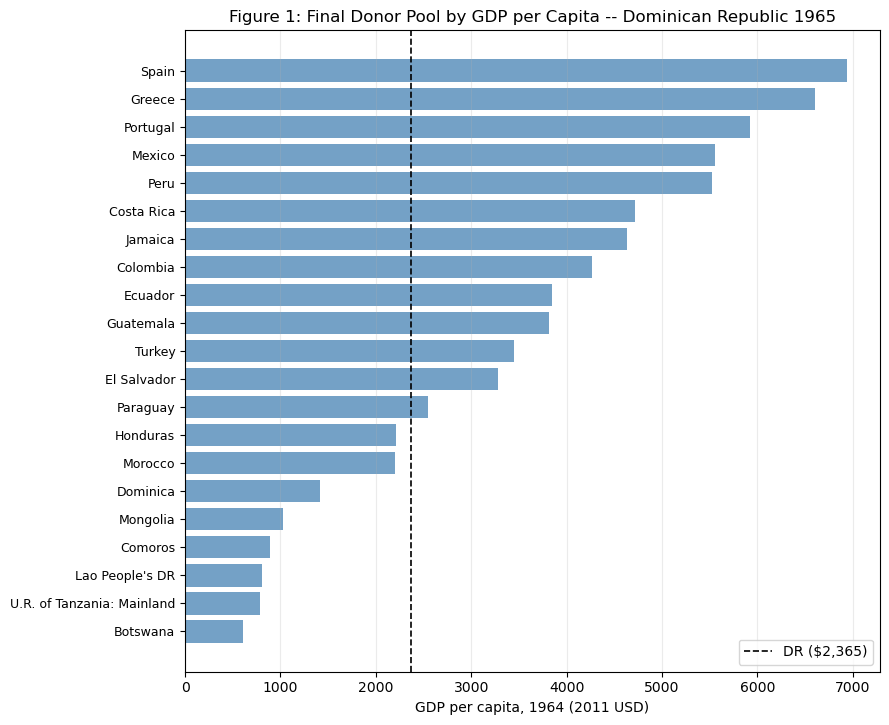

In [ ]:
pool_gdp_dr = (
    gdp_1964[gdp_1964["country"].isin(final_donor_pool_dr)]
    .sort_values("gdppc")
    .copy()
)

fig, ax = plt.subplots(figsize=(9, max(4, len(pool_gdp_dr) * 0.35)))
ax.barh(range(len(pool_gdp_dr)), pool_gdp_dr["gdppc"].values,
        color="steelblue", alpha=0.75)
ax.set_yticks(range(len(pool_gdp_dr)))
ax.set_yticklabels(pool_gdp_dr["country"].values, fontsize=9)
ax.axvline(dr_gdp_1964, color="black", linestyle="--", linewidth=1.2,
           label=f"DR (${dr_gdp_1964:,.0f})")
ax.set_xlabel("GDP per capita, 1964 (2011 USD)")
ax.set_title("Figure 1: Final Donor Pool by GDP per Capita -- Dominican Republic 1965")
ax.legend()
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Build panel and fit synthetic control

In [ ]:
BL_TO_MADDISON_DR = {
    "Dominican Rep.": "Dominican Republic",
    "Korea, Rep.": "Republic of Korea",
    "Venezuela, RB": "Venezuela",
    "Iran, Islamic Rep.": "Iran",
    "Egypt, Arab Rep.": "Egypt",
    "Syrian Arab Rep.": "Syrian Arab Republic",
    "Hong Kong, China": "Hong Kong",
    "Trinidad &Tobago": "Trinidad and Tobago",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Central African Rep.": "Central African Republic",
    "Lao PDR": "Laos",
    "Gambia, The": "Gambia",
}
schooling_data_dr = schooling_data.copy()
schooling_data_dr["country"] = schooling_data_dr["country"].replace(BL_TO_MADDISON_DR)

all_units_dr = [TREATED_COUNTRY_DR] + sorted(final_donor_pool_dr)
all_years_dr = list(range(PRE_TREATMENT_START_DR, POST_TREATMENT_END_DR + 1))

outcome_panel_dr = maddison_dr[
    maddison_dr["country"].isin(all_units_dr)
].pivot_table(index="year", columns="country", values="gdppc").reindex(all_years_dr)

for c in outcome_panel_dr.columns:
    n_nan = outcome_panel_dr[c].isna().sum()
    if 0 < n_nan <= 2:
        outcome_panel_dr[c] = outcome_panel_dr[c].interpolate(method="linear")

panel_long_dr = (
    outcome_panel_dr.reset_index()
    .melt(id_vars="year", var_name="unit", value_name="gdppc")
)
pwt_dr = pwt_data[["country", "year", "hc", "csh_i"]].rename(columns={"country": "unit"})
panel_long_dr = panel_long_dr.merge(pwt_dr, on=["unit", "year"], how="left")
bl_dr = schooling_data_dr[["country", "year", "school_years"]].rename(columns={"country": "unit"})
panel_long_dr = panel_long_dr.merge(bl_dr, on=["unit", "year"], how="left")

bl_years_dr = sorted(
    panel_long_dr[
        (panel_long_dr["unit"] == TREATED_COUNTRY_DR) &
        (panel_long_dr["year"] <= PRE_TREATMENT_END_DR) &
        (panel_long_dr["school_years"].notna())
    ]["year"].values
)

special_predictors_dr = [
    ("gdppc",       range(1950, 1955), "mean"),
    ("gdppc",       range(1955, 1960), "mean"),
    ("gdppc",       range(1960, 1965), "mean"),
    ("hc",          range(1951, 1965), "mean"),
    ("csh_i",       range(1950, 1965), "mean"),
    ("school_years", bl_years_dr,     "mean"),
]

donor_units_dr = [c for c in sorted(final_donor_pool_dr)
                  if has_all_preds(c, panel_long_dr, special_predictors_dr)]
dropped_pred_dr = set(sorted(final_donor_pool_dr)) - set(donor_units_dr)
if dropped_pred_dr:
    print(f"Dropped for missing predictors: {sorted(dropped_pred_dr)}")
print(f"Final donor pool after predictor check: {len(donor_units_dr)}")

dataprep_dr = Dataprep(
    foo=panel_long_dr,
    predictors=[],
    predictors_op="mean",
    time_predictors_prior=range(PRE_TREATMENT_START_DR, PRE_TREATMENT_END_DR + 1),
    special_predictors=special_predictors_dr,
    dependent="gdppc",
    unit_variable="unit",
    time_variable="year",
    treatment_identifier=TREATED_COUNTRY_DR,
    controls_identifier=donor_units_dr,
    time_optimize_ssr=range(PRE_TREATMENT_START_DR, PRE_TREATMENT_END_DR + 1),
)

synth_dr = Synth()
synth_dr.fit(dataprep=dataprep_dr, optim_method="Nelder-Mead", optim_initial="equal")
print("Model fitted.")

weights_raw_dr = synth_dr.weights(round=4)
if isinstance(weights_raw_dr, pd.Series):
    donor_weights_dr = weights_raw_dr
elif isinstance(weights_raw_dr, pd.DataFrame):
    donor_weights_dr = pd.Series(
        weights_raw_dr.iloc[:, -1].values, index=weights_raw_dr.iloc[:, 0].values
    )
else:
    donor_weights_dr = pd.Series(weights_raw_dr, index=donor_units_dr)
donor_weights_dr = donor_weights_dr.sort_values(ascending=False)

print("\nDonor weights:")
for c, w in donor_weights_dr.items():
    if w > 0.001:
        print(f"  {c:30s} {w:.4f}")

Dropped for missing predictors: ['Comoros', 'Dominica', "Lao People's DR", 'Mongolia', 'Turkey', 'U.R. of Tanzania: Mainland']
Final donor pool after predictor check: 15
Model fitted.

Donor weights:
  Botswana                       0.4022
  Paraguay                       0.2952
  Costa Rica                     0.0993
  Greece                         0.0988
  Honduras                       0.0922
  Guatemala                      0.0079
  Morocco                        0.0044


### Pre-treatment fit

In [ ]:
actual_dr = outcome_panel_dr[TREATED_COUNTRY_DR]
synthetic_dr = outcome_panel_dr[donor_weights_dr.index] @ donor_weights_dr

pre_mask_dr = actual_dr.index <= PRE_TREATMENT_END_DR
rmspe_dr = np.sqrt(((actual_dr[pre_mask_dr] - synthetic_dr[pre_mask_dr]) ** 2).mean())
corr_dr = actual_dr[pre_mask_dr].corr(synthetic_dr[pre_mask_dr])
print(f"Pre-treatment RMSPE:        {rmspe_dr:.1f}")
print(f"Pre-treatment correlation:  {corr_dr:.4f}")

Pre-treatment RMSPE:        69.7
Pre-treatment correlation:  0.9348


### Figure 2: Donor pool by SCM weights

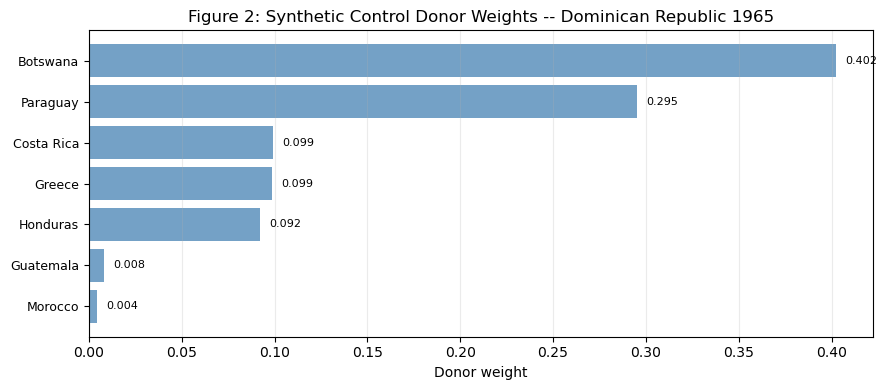

In [ ]:
nonzero_dr = donor_weights_dr[donor_weights_dr > 0.001].sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, len(nonzero_dr) * 0.38)))
ax.barh(range(len(nonzero_dr)), nonzero_dr.values, color="steelblue", alpha=0.75)
ax.set_yticks(range(len(nonzero_dr)))
ax.set_yticklabels(nonzero_dr.index, fontsize=9)
for i, w in enumerate(nonzero_dr.values):
    ax.text(w + 0.005, i, f"{w:.3f}", va="center", fontsize=8)
ax.set_xlabel("Donor weight")
ax.set_title("Figure 2: Synthetic Control Donor Weights -- Dominican Republic 1965")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Figure 3: Actual vs Synthetic Dominican Republic GDP per Capita

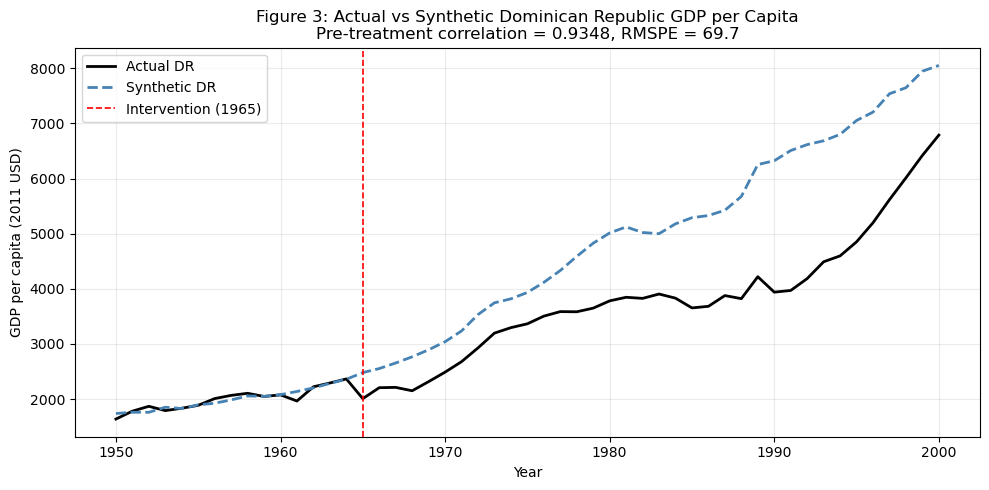

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(actual_dr.index, actual_dr.values, color="black", linewidth=2, label="Actual DR")
ax.plot(synthetic_dr.index, synthetic_dr.values, color="steelblue",
        linewidth=2, linestyle="--", label="Synthetic DR")
ax.axvline(INTERVENTION_YEAR_DR, color="red", linestyle="--",
           linewidth=1.2, label=f"Intervention ({INTERVENTION_YEAR_DR})")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita (2011 USD)")
ax.set_title(
    f"Figure 3: Actual vs Synthetic Dominican Republic GDP per Capita\n"
    f"Pre-treatment correlation = {corr_dr:.4f}, RMSPE = {rmspe_dr:.1f}"
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Figure 4: Per-capita GDP gap

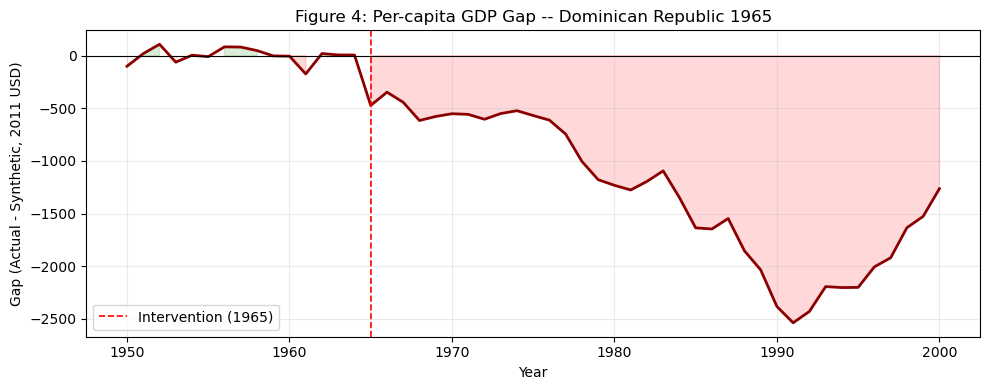

In [ ]:
gap_dr = actual_dr - synthetic_dr

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gap_dr.index, gap_dr.values, color="darkred", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(INTERVENTION_YEAR_DR, color="red", linestyle="--",
           linewidth=1.2, label=f"Intervention ({INTERVENTION_YEAR_DR})")
ax.fill_between(gap_dr.index, gap_dr.values, 0,
                where=(gap_dr.values < 0), alpha=0.15, color="red")
ax.fill_between(gap_dr.index, gap_dr.values, 0,
                where=(gap_dr.values >= 0), alpha=0.15, color="green")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (Actual - Synthetic, 2011 USD)")
ax.set_title("Figure 4: Per-capita GDP Gap -- Dominican Republic 1965")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation and limitations

The gap between actual and synthetic Dominican Republic GDP per capita after 1965 captures the combined effect of the US military intervention and the subsequent Balaguer regime on economic output. The donor pool includes Latin American, European, and other Atlantic-economy countries that shared comparable income levels and market structures in the early 1960s. Unlike Brazil, where actual GDP eventually outpaced the synthetic counterfactual, the Dominican Republic shows a consistent negative gap that starts immediately after 1965 and widens through the following three decades. The synthetic counterfactual grows substantially faster than actual DR output from the late 1960s onward, suggesting a lasting economic cost.

**Limitations:** Guatemala, El Salvador, Ecuador, and Paraguay are retained in the donor pool despite their own institutional irregularities. This is because excluding them would leave the DR without enough low-income Latin American comparators, but their inclusion means the synthetic control may partially reflect authoritarian economic patterns. Honduras is also retained despite Lopez Arellano's 1963 coup, as it provides the closest income-level match.

---

## Case Study 4: Ecuador 1963

On July 11, 1963, the Castro Jijon military junta overthrew President Carlos Julio Arosemena Monroy, citing his alleged communist sympathies and erratic behavior. The junta suspended the constitution and governed until 1966. This is the earliest of the five interventions analyzed in this project. Investment is excluded from the predictor set because Ecuador's PWT investment share (~60%) is implausibly high and likely reflects a data anomaly.

### Parameters and data

In [ ]:
TREATED_COUNTRY_EC = "Ecuador"
INTERVENTION_YEAR_EC = 1963
PRE_TREATMENT_START_EC = 1950
PRE_TREATMENT_END_EC = 1962
POST_TREATMENT_END_EC = 2000

maddison_ec = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_EC) &
    (maddison_full["year"] <= POST_TREATMENT_END_EC)
].copy()

### Candidate country screening

In [ ]:
ec_gdp_1962 = maddison_ec.loc[
    (maddison_ec["country"] == TREATED_COUNTRY_EC) &
    (maddison_ec["year"] == PRE_TREATMENT_END_EC), "gdppc"
].values[0]

gdp_1962 = (
    maddison_ec[maddison_ec["year"] == PRE_TREATMENT_END_EC][["country", "gdppc"]]
    .dropna(subset=["gdppc"])
    .copy()
)
gdp_1962["ratio"] = gdp_1962["gdppc"] / ec_gdp_1962

comparable_ec = gdp_1962[
    (gdp_1962["ratio"] >= 0.25) & (gdp_1962["ratio"] <= 3.00)
].copy()
print(f"Countries in GDP window: {len(comparable_ec)}")

Countries in GDP window: 120


### Exclusion criteria and final donor pool

Ecuador (July 1963) is the earliest case. Exclusions include socialist/command economies, oil-dependent states, Asian Tigers, city-states, active conflict zones, and other treated units. Brazil (April 1964, 9 months after) and the Dominican Republic (1965) are excluded as subsequent treated units. Guatemala (coup March 1963, 4 months before Ecuador) and Honduras (coup October 1963, 3 months after) are excluded as overlapping cases. Colombia, Peru, Paraguay, El Salvador, Jamaica, Mexico, and Costa Rica are retained as the core donor base.

In [ ]:
EXCLUSIONS_EC = {
    "Ecuador": "Treated country",
    "Brazil": "Castelo Branco coup April 1964; subsequent treated unit",
    "Dominican Republic": "Military intervention 1965; subsequent treated unit",
    "Chile": "Other treated unit (1973 coup)",
    "Argentina": "Other treated unit (1976 coup)",
    "Guatemala": "Military coup March 1963; contemporaneous (4 months before EC)",
    "Honduras": "Military coup October 1963; contemporaneous (3 months after EC)",
    "Bolivia": "Barrientos coup November 1964; within 2-year window",
    "Bolivia (Plurinational State of)": "Barrientos coup November 1964",
    "Syria": "Ba'ath coup March 1963; contemporaneous",
    "Syrian Arab Republic": "Ba'ath coup March 1963; contemporaneous",
    "Cuba": "Castro socialist command economy from 1959",
    "Haiti": "Duvalier dictatorship from 1957",
    "Nicaragua": "Somoza family dynastic rule",
    "Panama": "US Canal Zone economic distortion",
    "South Africa": "Apartheid regime; dual economy",
    "Algeria": "Ben Bella one-party state; nationalized economy",
    "Egypt": "Nasser Arab Socialism",
    "Romania": "Communist regime",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Hoxha communist regime",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Titoist socialist federation",
    "Yugoslavia": "Titoist socialist federation",
    "Croatia": "Part of socialist Yugoslavia",
    "Slovenia": "Part of socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav successor state",
    "Serbia": "Post-Yugoslav successor state",
    "Montenegro": "Post-Yugoslav successor state",
    "Macedonia": "Post-Yugoslav successor state",
    "TFYR of Macedonia": "Post-Yugoslav successor state",
    "Former USSR": "Soviet command economy",
    "Russian Federation": "USSR during study period",
    "Czechoslovakia": "Socialist 1948-1989",
    "Czech Republic": "Former Czechoslovakia, socialist",
    "Seychelles": "Socialist one-party state from 1977",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party state, state-directed economy",
    "Yemen": "Socialist 1967-1990",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil-dominated",
    "Venezuela": "OPEC; oil-dominated",
    "Libya": "Oil-dependent; Gaddafi revolution 1969",
    "Iran (Islamic Republic of)": "Oil-dependent",
    "Iran": "Oil-dependent",
    "Gabon": "Oil economy",
    "Iraq": "Oil economy; Ba'athist",
    "Bahrain": "Oil-dependent Gulf state",
    "Saudi Arabia": "Oil-dependent monarchy",
    "Trinidad and Tobago": "Oil-dependent economy",
    "Equatorial Guinea": "Oil economy",
    "Oman": "Oil economy",
    "Nigeria": "Oil economy; Biafra civil war 1967-1970",
    "Republic of Korea": "Asian Tiger; Park military from 1961",
    "Taiwan, Province of China": "Asian Tiger; KMT single-party",
    "Taiwan": "Asian Tiger; KMT single-party",
    "Malaysia": "Tiger Cub economy",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state; British Crown Colony",
    "Hong Kong": "City-state; British Crown Colony",
    "Puerto Rico": "US territory; federal transfers",
    "Barbados": "Small island economy",
    "Cyprus": "Small island; communal conflict",
    "Mauritius": "Small island economy",
    "Malta": "Small island; British military base",
    "Djibouti": "French colonial territory until 1977",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island economy",
    "Lebanon": "Civil war 1975-1990",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Tubman-era proxy state; coup 1980",
    "Namibia": "UNITA conflict spillover",
    "Swaziland": "ANC cross-border conflicts",
    "Angola": "Colonial war; civil war",
    "Cambodia": "Khmer Rouge ascendancy",
    "Sudan": "First Sudanese Civil War 1955-1972",
    "Sudan (Former)": "First Sudanese Civil War",
    "Palestine": "Incomplete data",
    "State of Palestine": "Incomplete data",
    "Jordan": "Incomplete predictor coverage",
    "Israel": "Military spending distortion",
    "Afghanistan": "Incomplete predictor coverage",
    "Thailand": "Sarit/Thanom military regimes",
    "Viet Nam": "War; multiple coups",
    "Indonesia": "Suharto coup 1965",
    "Benin": "Non-Atlantic", "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic", "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic", "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic", "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic", "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic", "Cote d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic", "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic", "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic", "United Republic of Tanzania": "Non-Atlantic",
    "Zambia": "Non-Atlantic", "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic", "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic", "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic", "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic", "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic", "Senegal": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic", "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic", "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic", "Philippines": "Non-Atlantic",
    "China": "Non-Atlantic",
}

RETAINED_NOTES_EC = {
    "Colombia": "Democratic through period; key LA comparator.",
    "Peru": "Democratic through 1968; Andean market economy.",
    "Paraguay": "Stroessner authoritarian but market economy. Limitation.",
    "El Salvador": "Military junta but market economy; CA peer. Limitation.",
    "Jamaica": "Caribbean peer economy.",
    "Mexico": "PRI single-party but market economy; key LA comparator.",
    "Costa Rica": "Democratic throughout; Central American benchmark.",
}

candidates_ec = comparable_ec[~comparable_ec["country"].isin(EXCLUSIONS_EC)].copy()

study_years_ec = set(range(PRE_TREATMENT_START_EC, POST_TREATMENT_END_EC + 1))
final_donor_pool_ec = []
dropped_ec = []
for _, row in candidates_ec.iterrows():
    c = row["country"]
    c_data = maddison_ec[
        (maddison_ec["country"] == c) & (maddison_ec["year"].isin(study_years_ec))
    ].dropna(subset=["gdppc"])
    if len(c_data) >= len(study_years_ec):
        final_donor_pool_ec.append(c)
    else:
        dropped_ec.append((c, len(c_data)))

if dropped_ec:
    print("Dropped for incomplete GDP coverage:")
    for c, n in dropped_ec:
        print(f"  {c}: {n}/{len(study_years_ec)} years")
print(f"Final donor pool: {len(final_donor_pool_ec)} countries")

Final donor pool: 19 countries


### Figure 1: Final donor pool by GDP per capita

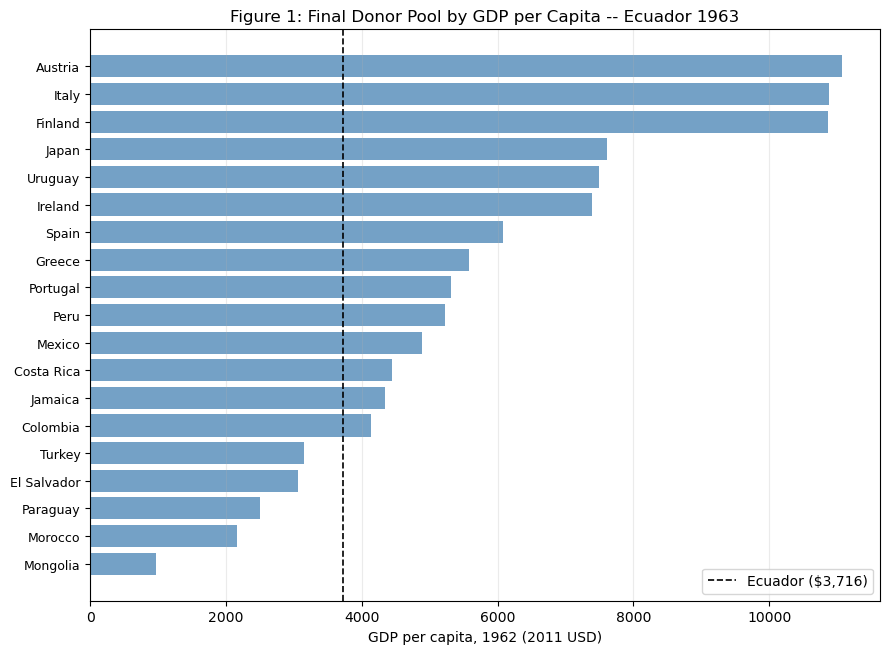

In [ ]:
pool_gdp_ec = (
    gdp_1962[gdp_1962["country"].isin(final_donor_pool_ec)]
    .sort_values("gdppc")
    .copy()
)

fig, ax = plt.subplots(figsize=(9, max(4, len(pool_gdp_ec) * 0.35)))
ax.barh(range(len(pool_gdp_ec)), pool_gdp_ec["gdppc"].values,
        color="steelblue", alpha=0.75)
ax.set_yticks(range(len(pool_gdp_ec)))
ax.set_yticklabels(pool_gdp_ec["country"].values, fontsize=9)
ax.axvline(ec_gdp_1962, color="black", linestyle="--", linewidth=1.2,
           label=f"Ecuador (${ec_gdp_1962:,.0f})")
ax.set_xlabel("GDP per capita, 1962 (2011 USD)")
ax.set_title("Figure 1: Final Donor Pool by GDP per Capita -- Ecuador 1963")
ax.legend()
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Build panel and fit synthetic control

Investment share is excluded because Ecuador's PWT csh_i is approximately 60% for the pre-treatment period, which is implausibly high and likely reflects a measurement issue. The analysis uses 5 predictors: three GDP sub-period averages, human capital index, and average years of schooling.

In [ ]:
BL_TO_MADDISON_EC = {
    "Dominican Rep.": "Dominican Republic",
    "Korea, Rep.": "Republic of Korea",
    "Venezuela, RB": "Venezuela",
    "Iran, Islamic Rep.": "Iran",
    "Egypt, Arab Rep.": "Egypt",
    "Syrian Arab Rep.": "Syrian Arab Republic",
    "Hong Kong, China": "Hong Kong",
    "Trinidad &Tobago": "Trinidad and Tobago",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Central African Rep.": "Central African Republic",
    "Lao PDR": "Laos",
    "Gambia, The": "Gambia",
}
schooling_data_ec = schooling_data.copy()
schooling_data_ec["country"] = schooling_data_ec["country"].replace(BL_TO_MADDISON_EC)

all_units_ec = [TREATED_COUNTRY_EC] + sorted(final_donor_pool_ec)
all_years_ec = list(range(PRE_TREATMENT_START_EC, POST_TREATMENT_END_EC + 1))

outcome_panel_ec = maddison_ec[
    maddison_ec["country"].isin(all_units_ec)
].pivot_table(index="year", columns="country", values="gdppc").reindex(all_years_ec)

for c in outcome_panel_ec.columns:
    n_nan = outcome_panel_ec[c].isna().sum()
    if 0 < n_nan <= 2:
        outcome_panel_ec[c] = outcome_panel_ec[c].interpolate(method="linear")

panel_long_ec = (
    outcome_panel_ec.reset_index()
    .melt(id_vars="year", var_name="unit", value_name="gdppc")
)
pwt_ec = pwt_data[["country", "year", "hc"]].rename(columns={"country": "unit"})
panel_long_ec = panel_long_ec.merge(pwt_ec, on=["unit", "year"], how="left")
bl_ec = schooling_data_ec[["country", "year", "school_years"]].rename(columns={"country": "unit"})
panel_long_ec = panel_long_ec.merge(bl_ec, on=["unit", "year"], how="left")

bl_years_ec = sorted(
    panel_long_ec[
        (panel_long_ec["unit"] == TREATED_COUNTRY_EC) &
        (panel_long_ec["year"] <= PRE_TREATMENT_END_EC) &
        (panel_long_ec["school_years"].notna())
    ]["year"].values
)

# 5 predictors -- investment excluded due to implausible PWT value (~60%)
special_predictors_ec = [
    ("gdppc",       range(1950, 1955), "mean"),
    ("gdppc",       range(1955, 1960), "mean"),
    ("gdppc",       range(1960, 1963), "mean"),
    ("hc",          range(1951, 1963), "mean"),
    ("school_years", bl_years_ec,     "mean"),
]

donor_units_ec = [c for c in sorted(final_donor_pool_ec)
                  if has_all_preds(c, panel_long_ec, special_predictors_ec)]
dropped_pred_ec = set(sorted(final_donor_pool_ec)) - set(donor_units_ec)
if dropped_pred_ec:
    print(f"Dropped for missing predictors: {sorted(dropped_pred_ec)}")
print(f"Final donor pool after predictor check: {len(donor_units_ec)}")

dataprep_ec = Dataprep(
    foo=panel_long_ec,
    predictors=[],
    predictors_op="mean",
    time_predictors_prior=range(PRE_TREATMENT_START_EC, PRE_TREATMENT_END_EC + 1),
    special_predictors=special_predictors_ec,
    dependent="gdppc",
    unit_variable="unit",
    time_variable="year",
    treatment_identifier=TREATED_COUNTRY_EC,
    controls_identifier=donor_units_ec,
    time_optimize_ssr=range(PRE_TREATMENT_START_EC, PRE_TREATMENT_END_EC + 1),
)

synth_ec = Synth()
synth_ec.fit(dataprep=dataprep_ec, optim_method="Nelder-Mead", optim_initial="equal")
print("Model fitted.")

weights_raw_ec = synth_ec.weights(round=4)
if isinstance(weights_raw_ec, pd.Series):
    donor_weights_ec = weights_raw_ec
elif isinstance(weights_raw_ec, pd.DataFrame):
    donor_weights_ec = pd.Series(
        weights_raw_ec.iloc[:, -1].values, index=weights_raw_ec.iloc[:, 0].values
    )
else:
    donor_weights_ec = pd.Series(weights_raw_ec, index=donor_units_ec)
donor_weights_ec = donor_weights_ec.sort_values(ascending=False)

print("\nDonor weights:")
for c, w in donor_weights_ec.items():
    if w > 0.001:
        print(f"  {c:30s} {w:.4f}")

Dropped for missing predictors: ['Mongolia', 'Turkey']
Final donor pool after predictor check: 17
Model fitted.

Donor weights:
  Morocco                        0.2531
  Paraguay                       0.2507
  El Salvador                    0.1409
  Ireland                        0.0919
  Japan                          0.0561
  Jamaica                        0.0483
  Uruguay                        0.0436
  Colombia                       0.0396
  Spain                          0.0343
  Costa Rica                     0.0337
  Mexico                         0.0079


### Pre-treatment fit

In [ ]:
actual_ec = outcome_panel_ec[TREATED_COUNTRY_EC]
synthetic_ec = outcome_panel_ec[donor_weights_ec.index] @ donor_weights_ec

pre_mask_ec = actual_ec.index <= PRE_TREATMENT_END_EC
rmspe_ec = np.sqrt(((actual_ec[pre_mask_ec] - synthetic_ec[pre_mask_ec]) ** 2).mean())
corr_ec = actual_ec[pre_mask_ec].corr(synthetic_ec[pre_mask_ec])
print(f"Pre-treatment RMSPE:        {rmspe_ec:.1f}")
print(f"Pre-treatment correlation:  {corr_ec:.4f}")

Pre-treatment RMSPE:        67.7
Pre-treatment correlation:  0.9580


### Figure 2: Donor pool by SCM weights

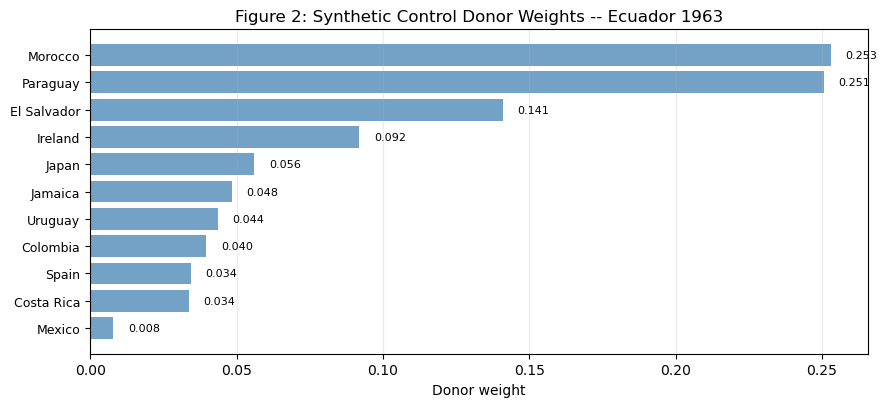

In [ ]:
nonzero_ec = donor_weights_ec[donor_weights_ec > 0.001].sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, len(nonzero_ec) * 0.38)))
ax.barh(range(len(nonzero_ec)), nonzero_ec.values, color="steelblue", alpha=0.75)
ax.set_yticks(range(len(nonzero_ec)))
ax.set_yticklabels(nonzero_ec.index, fontsize=9)
for i, w in enumerate(nonzero_ec.values):
    ax.text(w + 0.005, i, f"{w:.3f}", va="center", fontsize=8)
ax.set_xlabel("Donor weight")
ax.set_title("Figure 2: Synthetic Control Donor Weights -- Ecuador 1963")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Figure 3: Actual vs Synthetic Ecuador GDP per Capita

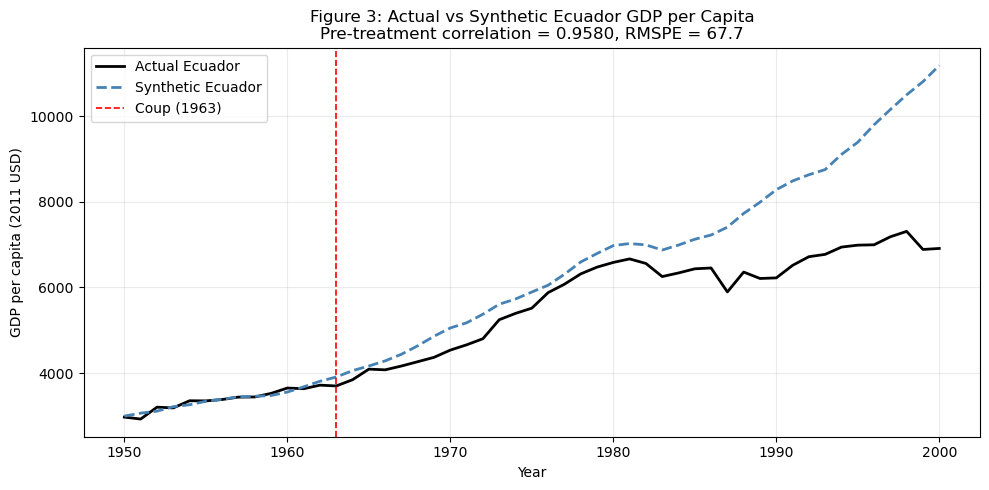

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(actual_ec.index, actual_ec.values, color="black", linewidth=2, label="Actual Ecuador")
ax.plot(synthetic_ec.index, synthetic_ec.values, color="steelblue",
        linewidth=2, linestyle="--", label="Synthetic Ecuador")
ax.axvline(INTERVENTION_YEAR_EC, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR_EC})")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita (2011 USD)")
ax.set_title(
    f"Figure 3: Actual vs Synthetic Ecuador GDP per Capita\n"
    f"Pre-treatment correlation = {corr_ec:.4f}, RMSPE = {rmspe_ec:.1f}"
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Figure 4: Per-capita GDP gap

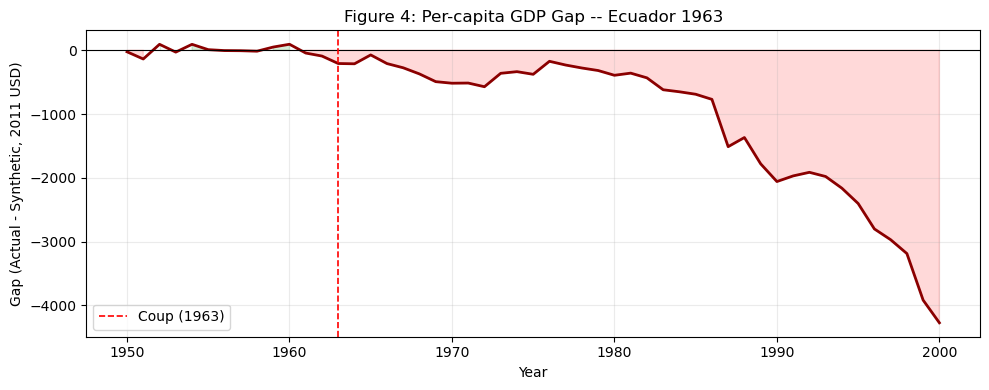

In [ ]:
gap_ec = actual_ec - synthetic_ec

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gap_ec.index, gap_ec.values, color="darkred", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(INTERVENTION_YEAR_EC, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR_EC})")
ax.fill_between(gap_ec.index, gap_ec.values, 0,
                where=(gap_ec.values < 0), alpha=0.15, color="red")
ax.fill_between(gap_ec.index, gap_ec.values, 0,
                where=(gap_ec.values >= 0), alpha=0.15, color="green")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (Actual - Synthetic, 2011 USD)")
ax.set_title("Figure 4: Per-capita GDP Gap -- Ecuador 1963")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation and limitations

The gap between actual and synthetic Ecuadorian GDP per capita following 1963 provides an estimate of the Castro Jijón junta's long-run economic effect. Both actual and synthetic Ecuador grow through the 1960s and 1970s, but the synthetic counterfactual grows faster at every stage and the divergence accelerates from the mid-1980s onward. The initial post-coup gap is small, which may represent the fact that the junta governed for only three years before returning power to civilians in 1966. However, the longer-run shortfall suggests lasting institutional damage that compounded over subsequent decades, consistent with the political instability that followed, including further coups in 1972 and repeated constitutional crises through the 1990s. Ecuador's 1970s oil boom, which appears in the data as a period of rapid actual GDP growth, was not enough to close the gap with the synthetic counterfactual, whose donor countries achieved comparable or greater growth without the institutional disruptions that followed the 1963 intervention.

**Limitations:** Investment (PWT csh_i) is excluded because Ecuador's pre-treatment value is approximately 60%, which is implausibly high and likely reflects a data recording issue in PWT 11.0. The core donor pool relies on South American and Caribbean countries, which may share some Ecuador-specific regional shocks during the post-treatment period.

---

## Case Study 5: Argentina 1976

On March 24, 1976, a military junta led by General Jorge Rafael Videla overthrew President Maria Estela Martinez de Peron (Isabelita). The regime, known as the Proceso de Reorganizacion Nacional, implemented a neoliberal economic shock program, suppressed unions, and conducted a campaign of state terror that killed an estimated 10,000--30,000 people. Argentina is the highest-income case in this project.

### Parameters and data

In [ ]:
TREATED_COUNTRY_AR = "Argentina"
INTERVENTION_YEAR_AR = 1976
PRE_TREATMENT_START_AR = 1950
PRE_TREATMENT_END_AR = 1975
POST_TREATMENT_END_AR = 2000

maddison_ar = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_AR) &
    (maddison_full["year"] <= POST_TREATMENT_END_AR)
].copy()

### Candidate country screening

Argentina is the highest-income treated country in this project. The ceiling is tightened to 175% of Argentina's 1975 GDP per capita (compared to 300% used for Brazil and DR), which focuses the donor pool on countries at or below Argentina's income level while still retaining the most directly comparable market economies.

In [ ]:
ar_gdp_1975 = maddison_ar.loc[
    (maddison_ar["country"] == TREATED_COUNTRY_AR) &
    (maddison_ar["year"] == PRE_TREATMENT_END_AR), "gdppc"
].values[0]

gdp_1975 = (
    maddison_ar[maddison_ar["year"] == PRE_TREATMENT_END_AR][["country", "gdppc"]]
    .dropna(subset=["gdppc"])
    .copy()
)
gdp_1975["ratio"] = gdp_1975["gdppc"] / ar_gdp_1975

comparable_ar = gdp_1975[
    (gdp_1975["ratio"] >= 0.25) & (gdp_1975["ratio"] <= 1.75)
].copy()
print(f"Countries in GDP window: {len(comparable_ar)}")

Countries in GDP window: 87


### Check investment plausibility

Argentina's PWT investment share is checked before including it as a predictor. If the pre-treatment mean exceeds 45%, the variable is dropped as implausible.

In [ ]:
ar_inv_data = pwt_data[
    (pwt_data["country"] == TREATED_COUNTRY_AR) &
    pwt_data["year"].between(PRE_TREATMENT_START_AR, PRE_TREATMENT_END_AR)
]["csh_i"].dropna()

ar_inv = ar_inv_data.mean() if len(ar_inv_data) > 0 else np.nan

if ar_inv > 0.45:
    INCLUDE_INVESTMENT_AR = False
    print(f"Investment share {ar_inv:.1%} is implausibly high. Excluding.")
elif np.isnan(ar_inv):
    INCLUDE_INVESTMENT_AR = False
    print("Investment share missing for Argentina. Excluding.")
else:
    INCLUDE_INVESTMENT_AR = True
    print(f"Investment share {ar_inv:.1%} is plausible. Including.")

Investment share 12.5% is plausible. Including.


### Exclusion criteria and final donor pool

Argentina's 1976 treatment is the latest case. Exclusions include all four other treated units, plus Uruguay (Bordaberry coup 1973), Peru (Morales Bermudez coup 1975), and Bolivia (Banzer dictatorship) as other intervention cases.

In [ ]:
EXCLUSIONS_AR = {
    "Argentina": "Treated country",
    "Chile": "Pinochet coup 1973; other treated unit",
    "Brazil": "Military dictatorship 1964-1985; other treated unit",
    "Dominican Republic": "Military coup 1965; other treated unit",
    "Ecuador": "Castro Jijon junta 1963; other treated unit",
    "Uruguay": "Bordaberry coup June 1973; contemporaneous Southern Cone dictatorship",
    "Peru": "Morales Bermudez coup August 1975; contemporaneous",
    "Bolivia": "Banzer dictatorship 1971-1978; contemporaneous",
    "Bolivia (Plurinational State of)": "Banzer dictatorship 1971-1978",
    "Cuba": "Castro socialist command economy from 1959",
    "Haiti": "Duvalier dictatorship from 1957",
    "Nicaragua": "Somoza dynastic rule; Sandinista revolution 1979",
    "Guatemala": "Military government; ongoing civil war",
    "El Salvador": "Military regime; civil war 1979-1992",
    "Honduras": "Lopez Arellano military 1963-1975; Melgar Castro coup 1975",
    "Panama": "Torrijos military regime from 1968; US Canal Zone distortion",
    "Paraguay": "Stroessner dictatorship from 1954",
    "Thailand": "Military regimes throughout",
    "Indonesia": "Suharto authoritarian regime from 1965",
    "Viet Nam": "War; communist reunification 1975",
    "South Africa": "Apartheid regime; dual economy",
    "Algeria": "Ben Bella/Boumedi one-party state; nationalized economy",
    "Egypt": "Nasser/Sadat Arab Socialism",
    "Syrian Arab Republic": "Ba'ath Arab Socialist regime",
    "Syria": "Ba'ath Arab Socialist regime",
    "Romania": "Communist regime",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Hoxha communist regime",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Titoist socialist federation",
    "Yugoslavia": "Titoist socialist federation",
    "Croatia": "Part of socialist Yugoslavia",
    "Slovenia": "Part of socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav successor state",
    "Serbia": "Post-Yugoslav successor state",
    "Montenegro": "Post-Yugoslav successor state",
    "Macedonia": "Post-Yugoslav successor state",
    "TFYR of Macedonia": "Post-Yugoslav successor state",
    "Former USSR": "Soviet command economy",
    "Russian Federation": "USSR during study period",
    "Czechoslovakia": "Socialist 1948-1989",
    "Czech Republic": "Former Czechoslovakia, socialist",
    "Seychelles": "Socialist one-party state from 1977",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party state, state-directed economy",
    "Yemen": "Socialist 1967-1990",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil-dominated; 1970s oil boom",
    "Venezuela": "OPEC; oil-dominated; 1970s oil boom",
    "Libya": "Oil-dependent; Gaddafi revolution 1969",
    "Iran (Islamic Republic of)": "Oil-dependent; Islamic Revolution 1979",
    "Iran": "Oil-dependent; Islamic Revolution 1979",
    "Gabon": "Oil economy",
    "Iraq": "Oil economy; Ba'athist government",
    "Bahrain": "Oil-dependent Gulf state",
    "Saudi Arabia": "Oil-dependent monarchy",
    "Kuwait": "Oil-dependent Gulf monarchy; OPEC member",
    "Trinidad and Tobago": "Oil-dependent economy; 1970s oil boom",
    "Equatorial Guinea": "Oil economy",
    "Oman": "Oil economy",
    "Nigeria": "Oil economy; military coups",
    "Republic of Korea": "Asian Tiger; Park/Chun military regimes",
    "Taiwan, Province of China": "Asian Tiger; KMT single-party",
    "Taiwan": "Asian Tiger; KMT single-party",
    "Malaysia": "Tiger Cub economy",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state; British Crown Colony",
    "Hong Kong": "City-state; British Crown Colony",
    "Puerto Rico": "US territory; federal transfers",
    "Barbados": "Small island economy",
    "Cyprus": "Small island; 1974 partition",
    "Mauritius": "Small island economy",
    "Malta": "Small island",
    "Djibouti": "French colonial territory until 1977",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island economy",
    "Jamaica": "Small island; Manley socialism 1972-1980; IMF crisis",
    "Iceland": "Micro-economy; structurally incomparable",
    "Luxembourg": "Micro-economy; financial center distortion",
    "Lebanon": "Civil war 1975-1990",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Coup 1980; civil war",
    "Namibia": "UNITA conflict spillover",
    "Swaziland": "ANC cross-border conflicts",
    "Angola": "Civil war post-independence",
    "Cambodia": "Khmer Rouge",
    "Sudan": "Civil war",
    "Sudan (Former)": "Civil war",
    "Palestine": "Incomplete data",
    "State of Palestine": "Incomplete data",
    "Jordan": "Incomplete predictor coverage",
    "Israel": "Yom Kippur War; military spending distortion",
    "Afghanistan": "Incomplete predictor coverage",
    "Benin": "Non-Atlantic", "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic", "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic", "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic", "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic", "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic", "Cameroon": "Non-Atlantic",
    "Cote d'Ivoire": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic", "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic", "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic", "United Republic of Tanzania": "Non-Atlantic",
    "Zambia": "Non-Atlantic", "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic", "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic", "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic", "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic", "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic", "Senegal": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic", "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic", "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic", "Philippines": "Non-Atlantic",
    "China": "Non-Atlantic",
}

RETAINED_NOTES_AR = {
    "Colombia": "Democratic through period; key LA comparator.",
    "Mexico": "PRI single-party but market economy; key LA comparator.",
    "Costa Rica": "Democratic throughout; key LA benchmark.",
    "Spain": "Franco died Nov 1975; democratic transition 1976-78. Limitation.",
    "Portugal": "Carnation Revolution April 1974; democratic transition. Limitation.",
    "Greece": "Metapolitefsi 1974; democratic transition. Limitation.",
    "Ireland": "Democratic throughout; mid-income European comparator.",
    "Japan": "Democratic throughout; high-growth comparator.",
    "Italy": "Democratic throughout; Mediterranean comparator.",
    "Austria": "Democratic throughout; European comparator.",
    "Finland": "Democratic throughout; European comparator.",
    "Turkey": "Democratic period 1973-1980 (pre-1980 coup). Limitation.",
    "Morocco": "Non-LA Atlantic comparator. Limitation.",
    "France": "Democratic throughout; European comparator.",
    "Germany": "Democratic throughout; European comparator.",
    "Belgium": "Democratic throughout; European comparator.",
    "United Kingdom": "Democratic throughout; European comparator.",
    "Australia": "Democratic throughout; high-income comparator.",
    "New Zealand": "Democratic throughout; high-income comparator.",
}

candidates_ar = comparable_ar[~comparable_ar["country"].isin(EXCLUSIONS_AR)].copy()

study_years_ar = set(range(PRE_TREATMENT_START_AR, POST_TREATMENT_END_AR + 1))
final_donor_pool_ar = []
dropped_ar = []
for _, row in candidates_ar.iterrows():
    c = row["country"]
    c_data = maddison_ar[
        (maddison_ar["country"] == c) & (maddison_ar["year"].isin(study_years_ar))
    ].dropna(subset=["gdppc"])
    if len(c_data) >= len(study_years_ar):
        final_donor_pool_ar.append(c)
    else:
        dropped_ar.append((c, len(c_data)))

if dropped_ar:
    print("Dropped for incomplete GDP coverage:")
    for c, n in dropped_ar:
        print(f"  {c}: {n}/{len(study_years_ar)} years")
print(f"Final donor pool: {len(final_donor_pool_ar)} countries")

Final donor pool: 22 countries


### Figure 1: Final donor pool by GDP per capita

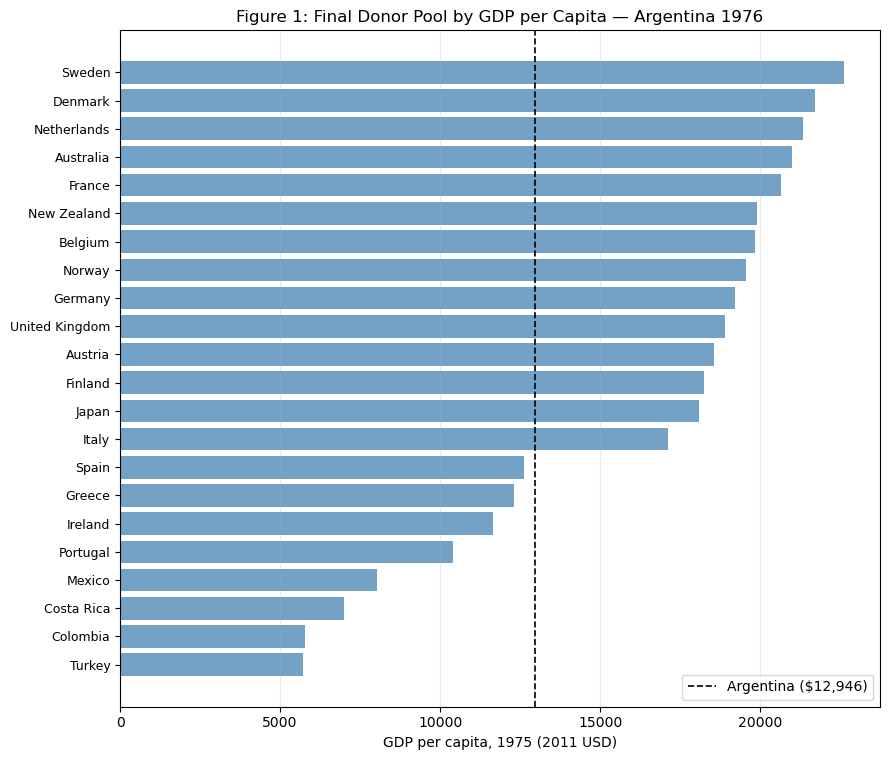

In [ ]:
pool_gdp_ar = (
    gdp_1975[gdp_1975["country"].isin(final_donor_pool_ar)]
    .sort_values("gdppc")
    .copy()
)

fig, ax = plt.subplots(figsize=(9, max(4, len(pool_gdp_ar) * 0.35)))
ax.barh(range(len(pool_gdp_ar)), pool_gdp_ar["gdppc"].values,
        color="steelblue", alpha=0.75)
ax.set_yticks(range(len(pool_gdp_ar)))
ax.set_yticklabels(pool_gdp_ar["country"].values, fontsize=9)
ax.axvline(ar_gdp_1975, color="black", linestyle="--", linewidth=1.2,
           label=f"Argentina (${ar_gdp_1975:,.0f})")
ax.set_xlabel("GDP per capita, 1975 (2011 USD)")
ax.set_title("Figure 1: Final Donor Pool by GDP per Capita — Argentina 1976")
ax.legend()
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Build predictor panel and fit synthetic control

In [ ]:
BL_TO_MADDISON_AR = {
    "Dominican Rep.": "Dominican Republic",
    "Korea, Rep.": "Republic of Korea",
    "Venezuela, RB": "Venezuela",
    "Iran, Islamic Rep.": "Iran",
    "Egypt, Arab Rep.": "Egypt",
    "Syrian Arab Rep.": "Syrian Arab Republic",
    "Hong Kong, China": "Hong Kong",
    "Trinidad &Tobago": "Trinidad and Tobago",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Central African Rep.": "Central African Republic",
    "Lao PDR": "Laos",
    "Gambia, The": "Gambia",
}
schooling_data_ar = schooling_data.copy()
schooling_data_ar["country"] = schooling_data_ar["country"].replace(BL_TO_MADDISON_AR)

countries_of_interest_ar = [TREATED_COUNTRY_AR] + sorted(final_donor_pool_ar)
all_years_ar = list(range(PRE_TREATMENT_START_AR, POST_TREATMENT_END_AR + 1))

outcome_panel_ar = maddison_ar[
    maddison_ar["country"].isin(countries_of_interest_ar)
].pivot_table(index="year", columns="country", values="gdppc").reindex(all_years_ar)

for c in outcome_panel_ar.columns:
    n_nan = outcome_panel_ar[c].isna().sum()
    if 0 < n_nan <= 2:
        outcome_panel_ar[c] = outcome_panel_ar[c].interpolate(method="linear")

panel_long_ar = (
    outcome_panel_ar.reset_index()
    .melt(id_vars="year", var_name="unit", value_name="gdppc")
)
pwt_cols_ar = ["country", "year", "hc"]
if INCLUDE_INVESTMENT_AR:
    pwt_cols_ar.append("csh_i")
pwt_merge_ar = pwt_data[pwt_cols_ar].rename(columns={"country": "unit"})
panel_long_ar = panel_long_ar.merge(pwt_merge_ar, on=["unit", "year"], how="left")
bl_merge_ar = schooling_data_ar[["country", "year", "school_years"]].rename(columns={"country": "unit"})
panel_long_ar = panel_long_ar.merge(bl_merge_ar, on=["unit", "year"], how="left")

bl_years_ar = sorted(
    panel_long_ar[
        (panel_long_ar["unit"] == TREATED_COUNTRY_AR) &
        (panel_long_ar["year"] <= PRE_TREATMENT_END_AR) &
        (panel_long_ar["school_years"].notna())
    ]["year"].values
)

special_predictors_ar = [
    ("gdppc", range(1950, 1959), "mean"),
    ("gdppc", range(1959, 1968), "mean"),
    ("gdppc", range(1968, 1976), "mean"),
    ("hc", range(PRE_TREATMENT_START_AR, PRE_TREATMENT_END_AR + 1), "mean"),
    ("school_years", bl_years_ar, "mean"),
]
if INCLUDE_INVESTMENT_AR:
    special_predictors_ar.append(
        ("csh_i", range(PRE_TREATMENT_START_AR, PRE_TREATMENT_END_AR + 1), "mean")
    )

donor_units_ar = [c for c in sorted(final_donor_pool_ar)
                  if has_all_preds(c, panel_long_ar, special_predictors_ar)]
dropped_pred_ar = set(sorted(final_donor_pool_ar)) - set(donor_units_ar)
if dropped_pred_ar:
    print(f"Dropped for missing predictors: {sorted(dropped_pred_ar)}")
print(f"Final donor pool after predictor check: {len(donor_units_ar)}")

dataprep_ar = Dataprep(
    foo=panel_long_ar,
    predictors=[],
    predictors_op="mean",
    time_predictors_prior=range(PRE_TREATMENT_START_AR, PRE_TREATMENT_END_AR + 1),
    special_predictors=special_predictors_ar,
    dependent="gdppc",
    unit_variable="unit",
    time_variable="year",
    treatment_identifier=TREATED_COUNTRY_AR,
    controls_identifier=donor_units_ar,
    time_optimize_ssr=range(PRE_TREATMENT_START_AR, PRE_TREATMENT_END_AR + 1),
)

synth_ar = Synth()
synth_ar.fit(dataprep=dataprep_ar, optim_method="Nelder-Mead", optim_initial="equal")
print("Model fitted.")

weights_raw_ar = synth_ar.weights(round=4)
if isinstance(weights_raw_ar, pd.Series):
    donor_weights_ar = weights_raw_ar
elif isinstance(weights_raw_ar, pd.DataFrame):
    donor_weights_ar = pd.Series(
        weights_raw_ar.iloc[:, -1].values, index=weights_raw_ar.iloc[:, 0].values
    )
else:
    donor_weights_ar = pd.Series(weights_raw_ar, index=donor_units_ar)
donor_weights_ar = donor_weights_ar.sort_values(ascending=False)

print("\nDonor weights:")
for c, w in donor_weights_ar.items():
    if w > 0.001:
        print(f"  {c:30s} {w:.4f}")

Dropped for missing predictors: ['Turkey']
Final donor pool after predictor check: 21
Model fitted.

Donor weights:
  Costa Rica                     0.5366
  New Zealand                    0.2473
  United Kingdom                 0.2161


### Pre-treatment fit

In [ ]:
synthetic_ar = outcome_panel_ar[donor_weights_ar.index] @ donor_weights_ar
actual_ar = outcome_panel_ar[TREATED_COUNTRY_AR]

pre_mask_ar = actual_ar.index <= PRE_TREATMENT_END_AR
rmspe_ar = np.sqrt(((actual_ar[pre_mask_ar] - synthetic_ar[pre_mask_ar]) ** 2).mean())
corr_ar = actual_ar[pre_mask_ar].corr(synthetic_ar[pre_mask_ar])
print(f"Pre-treatment RMSPE: {rmspe_ar:.1f}")
print(f"Pre-treatment correlation: {corr_ar:.4f}")

Pre-treatment RMSPE: 394.7
Pre-treatment correlation: 0.9744


### Figure 2: Donor pool by SCM weights

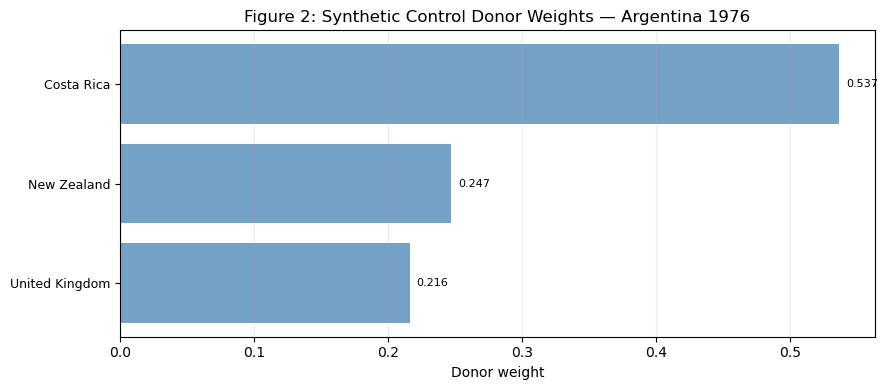

In [ ]:
nonzero_ar = donor_weights_ar[donor_weights_ar > 0.001].sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, len(nonzero_ar) * 0.38)))
ax.barh(range(len(nonzero_ar)), nonzero_ar.values, color="steelblue", alpha=0.75)
ax.set_yticks(range(len(nonzero_ar)))
ax.set_yticklabels(nonzero_ar.index, fontsize=9)
for i, w in enumerate(nonzero_ar.values):
    ax.text(w + 0.005, i, f"{w:.3f}", va="center", fontsize=8)
ax.set_xlabel("Donor weight")
ax.set_title("Figure 2: Synthetic Control Donor Weights — Argentina 1976")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

### Figure 3: Actual vs Synthetic Argentina GDP per Capita

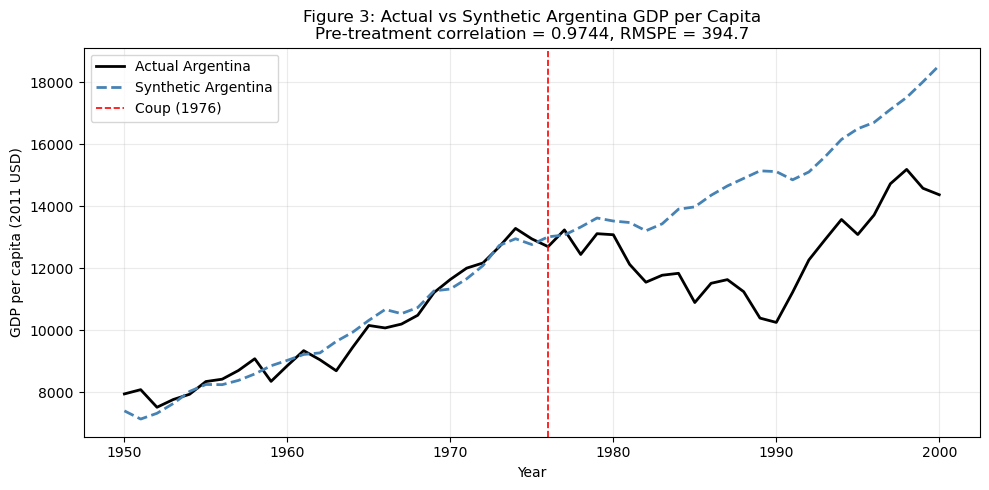

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(actual_ar.index, actual_ar.values, color="black", linewidth=2, label="Actual Argentina")
ax.plot(synthetic_ar.index, synthetic_ar.values, color="steelblue",
        linewidth=2, linestyle="--", label="Synthetic Argentina")
ax.axvline(INTERVENTION_YEAR_AR, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR_AR})")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita (2011 USD)")
ax.set_title(
    f"Figure 3: Actual vs Synthetic Argentina GDP per Capita\n"
    f"Pre-treatment correlation = {corr_ar:.4f}, RMSPE = {rmspe_ar:.1f}"
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Figure 4: Per-capita GDP gap

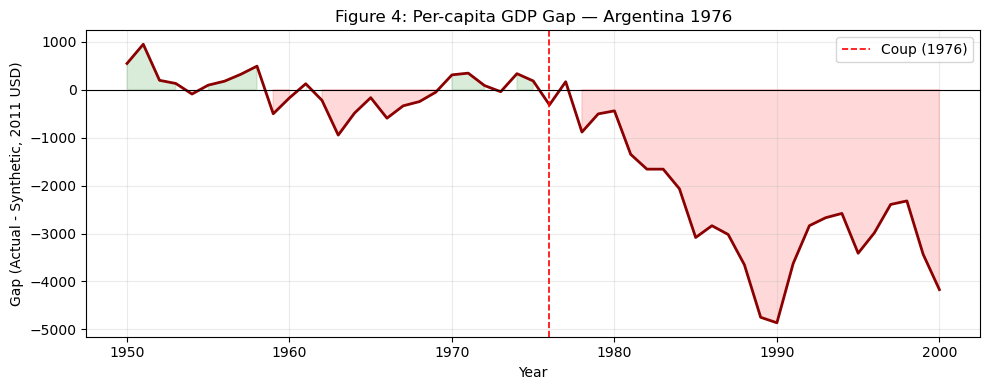

In [ ]:
gap_ar = actual_ar - synthetic_ar

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gap_ar.index, gap_ar.values, color="darkred", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(INTERVENTION_YEAR_AR, color="red", linestyle="--",
           linewidth=1.2, label=f"Coup ({INTERVENTION_YEAR_AR})")
ax.fill_between(gap_ar.index, gap_ar.values, 0,
                where=(gap_ar.values < 0), alpha=0.15, color="red")
ax.fill_between(gap_ar.index, gap_ar.values, 0,
                where=(gap_ar.values >= 0), alpha=0.15, color="green")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (Actual - Synthetic, 2011 USD)")
ax.set_title("Figure 4: Per-capita GDP Gap — Argentina 1976")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation and limitations

Pre-treatment fit is strong despite Argentina's well-documented political instability during the 1950s and 1960s, including the Revolución Libertadora (1955), Frondizi's ouster (1962), and the Revolución Argentina (1966–1973), all of which appear in the data as short-lived GDP dips that the synthetic tracks closely. After 1976, actual Argentina falls decisively below the synthetic counterfactual and never recovers over the remaining 25 years of the study period. The gap widens first during the Proceso itself, as Martínez de Hoz's financial liberalization program produced mounting foreign debt and deindustrialization, and then catastrophically during the late 1980s, when the debt overhang left by the dictatorship culminated in hyperinflation under Alfonsín. The partial recovery during the Menem-era convertibility plan of the 1990s narrows the gap somewhat but does not close it. The Falklands War (1982) and the broader Latin American debt crisis also introduce post-treatment shocks that the SCM cannot cleanly attribute to the 1976 coup alone.

**Limitations:** Spain, Portugal, and Greece are retained in the donor pool despite undergoing democratic transitions in 1974--1978, the opposite political trajectory from Argentina. The post-1976 Falklands War (1982) and hyperinflation episodes introduce post-treatment shocks that the SCM cannot attribute to the 1976 coup specifically.

### Conclusion
Collectively, the five case studies suggest US-backed interventions in Latin America negatively impact GDP per capita outcomes. Chile and Argentina show the largest and most persistent negative gaps: actual GDP falls well below the synthetic counterfactual after the intervention and remains there through 2000, consistent with lasting institutional damage. The Dominican Republic follows a similar trajectory, with a steady negative gap opening after 1965, though the concurrent US military occupation makes it impossible to isolate the coup's effect from the effects of foreign intervention. Ecuador shows a more minimal difference, modest in the first decade but widening from the 1980s onward, suggesting that the economic costs of its 1963 coup compounded through subsequent political instability and not as an immediate shock. Brazil is the outlier. After a brief dip, actual GDP rises above the synthetic counterfactual from the early 1970s onward, reflecting the military government's aggressive state-led industrialization, though whether this represents genuine long-run gain or growth borrowed through unsustainable debt remains an open question. The variation across cases demonstrates that the economic consequences of military intervention depend heavily on the context of the country such as the specific policies adopted by the regime, the institutional baseline at the time of the coup, and the external economic environment.